In [1]:
!pip install scanpy anndata commot mygene

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.5/64.5 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 2.6 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of karateclub to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6

In [2]:
!git clone https://github.com/ZhangLabGT/scDisInFact/

Cloning into 'scDisInFact'...
remote: Enumerating objects: 2119, done.
remote: Counting objects: 100% (673/673), done.
remote: Compressing objects: 100% (383/383), done.
remote: Total 2119 (delta 353), reused 601 (delta 281), pack-reused 1446 (from 1)
Receiving objects: 100% (2119/2119), 1.00 GiB | 40.79 MiB/s, done.
Resolving deltas: 100% (731/731), done.


In [3]:
%cd scDisInFact

/kaggle/working/scDisInFact


In [4]:
!pip install .

Processing /kaggle/working/scDisInFact
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 117.1 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 93.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 34.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 8.2 MB/s eta 0:00:000:00:0100:01
  Created wheel for scDis

In [5]:
import scanpy as sc
import anndata
import commot as ct # install via pip or from source
import pandas as pd
import numpy as np
from scipy import sparse
import mygene
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import torch
from sklearn.metrics.pairwise import euclidean_distances
from scipy.stats import mannwhitneyu
import networkx as nx
import re
from scDisInFact import scdisinfact, create_scdisinfact_dataset
import seaborn as sns
from sklearn.metrics import pairwise_distances
from sklearn.neighbors import KDTree
from sklearn.neighbors import NearestNeighbors
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm
from sklearn.cluster import AgglomerativeClustering
import plotly.graph_objects as go
from scipy.cluster.hierarchy import dendrogram, linkage

2025-11-27 08:34:40.858399: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764232481.079767      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764232481.141793      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [ ]:
# pip install --user scikit-misc

# COMMOT: GENERATION OF SPOT LEVEL SCORES

## DATASET-1: BREAST-CANCER-NATGENET

In [ ]:
adata = sc.read_h5ad("/kaggle/input/natgenet-breast-cancer/cb75cb91-a252-4651-9d3a-613fbc7ca85e.h5ad" ) 

In [ ]:
commot_cancer = sc.read_h5ad("/kaggle/input/commot-dataset/COMMOT_cancer.h5ad")

In [ ]:
commot_cancer

In [ ]:
# adata

In [ ]:
# adata.obs["cell_type"].value_counts()

In [ ]:
# print(adata)

In [ ]:
# adata.var_names_make_unique()
# adata.raw = adata
# sc.pp.normalize_total(adata, inplace=True)
# sc.pp.log1p(adata)

In [ ]:
# df_cellchat = ct.pp.ligand_receptor_database(
#     species='human',
#     signaling_type='Secreted Signaling',   # or 'All' to include ECM & contact
#     database='CellChat'
# )
# df_cellchat.columns = ["ligand", "receptor", "pathway", "signaling_type"]
# print(df_cellchat.shape)

# df_lr = df_cellchat.copy()
# df_lr['ligand']   = df_lr['ligand'].str.upper()
# df_lr['receptor'] = df_lr['receptor'].str.upper()

# # 2) Build a symbol -> Ensembl map (human)
# mg = mygene.MyGeneInfo()
# symbols = sorted(set(df_lr['ligand']).union(
#     s for r in df_lr['receptor'] for s in r.split('_')
# ))
# q = mg.querymany(symbols, scopes='symbol', fields='ensembl.gene,taxid',
#                  species='human', as_dataframe=True)

# def pick_ens(v):
#     # v can be dict/list/str/NaN; return a single Ensembl gene id (string) or None
#     if isinstance(v, list):
#         v = v[0]
#     if isinstance(v, dict):
#         return v.get('gene')
#     return v

# map_sym2ens = q[q['taxid']==9606]['ensembl.gene'].map(pick_ens).dropna().astype(str).to_dict()

# # 3) Remap LR table to Ensembl (drop pairs where any subunit fails to map)
# def map_receptor_to_ens(r):
#     subs = r.split('_')
#     ens = [map_sym2ens.get(s) for s in subs]
#     if any(x is None for x in ens):
#         return np.nan
#     return '_'.join(ens)

# df_lr_ens = df_lr.copy()
# df_lr_ens['ligand']   = df_lr_ens['ligand'].map(map_sym2ens)
# df_lr_ens['receptor'] = df_lr_ens['receptor'].apply(map_receptor_to_ens)
# df_lr_ens = df_lr_ens.dropna(subset=['ligand','receptor'])

# # 4) If your var_names have Ensembl versions, strip them
# adata.var_names = adata.var_names.str.replace(r'\.\d+$', '', regex=True)


In [ ]:
# df_cellchat_filtered = ct.pp.filter_lr_database(df_lr_ens, adata, min_cell_pct=0.03) # 
# print(df_cellchat_filtered.shape)

In [ ]:
# adata.obsm['spatial']

In [ ]:
# ct.tl.spatial_communication(adata,
#     database_name='cellchat', df_ligrec=df_cellchat_filtered, dis_thr=500, heteromeric=True, pathway_sum=True)

In [ ]:
commot_cancer.obsp.keys()

In [ ]:
commot_cancer.uns['commot-cellchat-info']

In [ ]:
# adata.write("./adata1.h5ad")

In [ ]:
ccc_psap = commot_cancer.obsp['commot-cellchat-ENSG00000135046-ENSG00000171051'].toarray()

# Convert to DataFrame for inspection
ccc_psap_df = pd.DataFrame(
    ccc_psap,
    index=commot_cancer.obs_names,
    columns=commot_cancer.obs_names
)
print(ccc_psap_df.head())

In [ ]:
nonzero = ccc_psap_df.values[ccc_psap_df.values > 0]
plt.hist(nonzero, bins=100)
plt.xlabel("COMMOT score")
plt.ylabel("Count")
plt.title("Distribution of non-zero COMMOT scores")
plt.show()

np.percentile(nonzero, [50, 75, 90, 95, 99])

In [ ]:
cutoff = np.percentile(nonzero, 99)
cutoff

In [ ]:
nonzero_edges = (
    ccc_psap_df
    .stack()                           # turn matrix into long format
    .reset_index()                     # columns: sender, receiver, value
    .rename(columns={"level_0": "sender", "level_1": "receiver", 0: "score"})
)
nonzero_edges = nonzero_edges[nonzero_edges["score"] >= cutoff]

print(f"Non-zero edges: {nonzero_edges.shape[0]}")
nonzero_edges.head(9)

In [ ]:
nonzero_edges["sender_celltype"] = nonzero_edges["sender"].map(commot_cancer.obs["cell_type"])
nonzero_edges["receiver_celltype"] = nonzero_edges["receiver"].map(commot_cancer.obs["cell_type"])

# Check
nonzero_edges.head()

In [ ]:
coords = pd.DataFrame(
    commot_cancer.obsm["spatial"],
    index=commot_cancer.obs_names,
    columns=["x", "y"]              # if your tech uses a different order, swap here
)

# 2) Map coords onto the nonzero_edges table
nonzero_edges["sender_x"] = nonzero_edges["sender"].map(coords["x"])
nonzero_edges["sender_y"] = nonzero_edges["sender"].map(coords["y"])
nonzero_edges["receiver_x"] = nonzero_edges["receiver"].map(coords["x"])
nonzero_edges["receiver_y"] = nonzero_edges["receiver"].map(coords["y"])

In [ ]:
ligand = "ENSG00000135046"
receptor = "ENSG00000171051"

# Insert ligand and receptor as first two columns
nonzero_edges.insert(0, "ligand", ligand)
nonzero_edges.insert(1, "receptor", receptor)

In [ ]:
nonzero_edges.head()

In [ ]:
import pandas as pd
import numpy as np

# --- prepare coordinate & cell-type lookup tables ---
coords = pd.DataFrame(
    commot_cancer.obsm["spatial"],
    index=commot_cancer.obs_names,
    columns=["x", "y"]
)
cell_types = commot_cancer.obs["cell_type"]

# --- collect results for each LR matrix ---
all_edges = []

for key in commot_cancer.obsp.keys():
    if not key.startswith("commot-cellchat-ENSG"):
        continue
    # # optional: stop at ACTIVIN if you only want up to that key
    # if "ENSG" not in key:
    #     break

    # extract ligand/receptor names
    parts = key.split("-")
    if len(parts) < 4:
        continue
    ligand, receptor = parts[-2], parts[-1]

    # extract matrix and skip empty ones
    mat = commot_cancer.obsp[key].toarray()
    if not np.any(mat):
        continue

    # convert to long format
    df = (
        pd.DataFrame(mat, index=commot_cancer.obs_names, columns=commot_cancer.obs_names)
        .stack()
        .reset_index()
        .rename(columns={"level_0": "sender", "level_1": "receiver", 0: "score"})
    )

    # nonzero = df[df["score"] > 0]
    # np.percentile(nonzero["score"], [50, 75, 90, 95, 99])
    # cutoff = np.percentile(nonzero["score"], 99)
    df = df[df["score"] > 0]

    # add metadata
    df["ligand"] = ligand
    df["receptor"] = receptor
    df["sender_celltype"] = df["sender"].map(cell_types)
    df["receiver_celltype"] = df["receiver"].map(cell_types)
    df["sender_x"] = df["sender"].map(coords["x"])
    df["sender_y"] = df["sender"].map(coords["y"])
    df["receiver_x"] = df["receiver"].map(coords["x"])
    df["receiver_y"] = df["receiver"].map(coords["y"])

    # reorder columns for clarity
    df = df[
        [
            "ligand", "receptor", "sender", "receiver", "score",
            "sender_celltype", "receiver_celltype",
            "sender_x", "sender_y", "receiver_x", "receiver_y"
        ]
    ]

    all_edges.append(df)

# --- combine all LR edge tables ---
edges_combined = pd.concat(all_edges, ignore_index=True)
edges_combined.head()


In [ ]:
cancer_edges = edges_combined.copy()

In [ ]:
cancer_edges.shape

In [ ]:
edges_combined.head(30)

In [ ]:
edges_combined.to_csv("cancer_edges.csv", index=False)

## DATASET-2:BREAST_NORMAL

In [ ]:
adata_norm = sc.read_h5ad("/kaggle/input/normal-breast-kumar/4893ba2b-f564-41d9-a6a0-d09301fa4706.h5ad")

In [ ]:
adata_norm.obs["cell_type"].value_counts()

In [ ]:
adata_filt = adata_norm[adata_norm.obs["in_tissue"] == 1].copy()

In [ ]:
adata_filt

In [ ]:
adata_filt.obs["cell_type"].value_counts()

In [ ]:
print(adata_norm.obs["in_tissue"].value_counts())

In [ ]:
adata_filt.var_names_make_unique()
adata_filt.raw = adata_filt
sc.pp.normalize_total(adata_filt, inplace=True)
sc.pp.log1p(adata_filt)

In [ ]:
df_cellchat = ct.pp.ligand_receptor_database(
    species='human',
    signaling_type='Secreted Signaling',   # or 'All' to include ECM & contact
    database='CellChat'
)
df_cellchat.columns = ["ligand", "receptor", "pathway", "signaling_type"]
print(df_cellchat.shape)

df_lr = df_cellchat.copy()
df_lr['ligand']   = df_lr['ligand'].str.upper()
df_lr['receptor'] = df_lr['receptor'].str.upper()

# 2) Build a symbol -> Ensembl map (human)
mg = mygene.MyGeneInfo()
symbols = sorted(set(df_lr['ligand']).union(
    s for r in df_lr['receptor'] for s in r.split('_')
))
q = mg.querymany(symbols, scopes='symbol', fields='ensembl.gene,taxid',
                 species='human', as_dataframe=True)

def pick_ens(v):
    # v can be dict/list/str/NaN; return a single Ensembl gene id (string) or None
    if isinstance(v, list):
        v = v[0]
    if isinstance(v, dict):
        return v.get('gene')
    return v

map_sym2ens = q[q['taxid']==9606]['ensembl.gene'].map(pick_ens).dropna().astype(str).to_dict()

# 3) Remap LR table to Ensembl (drop pairs where any subunit fails to map)
def map_receptor_to_ens(r):
    subs = r.split('_')
    ens = [map_sym2ens.get(s) for s in subs]
    if any(x is None for x in ens):
        return np.nan
    return '_'.join(ens)

df_lr_ens = df_lr.copy()
df_lr_ens['ligand']   = df_lr_ens['ligand'].map(map_sym2ens)
df_lr_ens['receptor'] = df_lr_ens['receptor'].apply(map_receptor_to_ens)
df_lr_ens = df_lr_ens.dropna(subset=['ligand','receptor'])

# 4) If your var_names have Ensembl versions, strip them
adata_filt.var_names = adata_filt.var_names.str.replace(r'\.\d+$', '', regex=True)

In [ ]:
df_cellchat_filtered = ct.pp.filter_lr_database(df_lr_ens, adata_filt, min_cell_pct=0.03) # 
print(df_cellchat_filtered.shape)

In [ ]:
ct.tl.spatial_communication(adata_filt,
    database_name='cellchat', df_ligrec=df_cellchat_filtered, dis_thr=500, heteromeric=True, pathway_sum=True)

In [ ]:
adata_filt.obsp.keys()

In [ ]:
adata_filt.write("./adata2.h5ad")

In [ ]:
adata_filt.uns['commot-cellchat-info']

In [ ]:
ccc_psap = adata_filt.obsp['commot-cellchat-ENSG00000078401-ENSG00000136160'].toarray()

# Convert to DataFrame for inspection
ccc_psap_df = pd.DataFrame(
    ccc_psap,
    index=adata_filt.obs_names,
    columns=adata_filt.obs_names
)
print(ccc_psap_df.head())

In [ ]:
nonzero = ccc_psap_df.values[ccc_psap_df.values > 0]
plt.hist(nonzero, bins=100)
plt.xlabel("COMMOT score")
plt.ylabel("Count")
plt.title("Distribution of non-zero COMMOT scores")
plt.show()

np.percentile(nonzero, [50, 75, 90, 95, 99])

In [ ]:
cutoff = np.percentile(nonzero, 99)
cutoff

In [ ]:
nonzero_edges = (
    ccc_psap_df
    .stack()                           # turn matrix into long format
    .reset_index()                     # columns: sender, receiver, value
    .rename(columns={"level_0": "sender", "level_1": "receiver", 0: "score"})
)
nonzero_edges = nonzero_edges[nonzero_edges["score"] >= cutoff]

print(f"Non-zero edges: {nonzero_edges.shape[0]}")
nonzero_edges.head(9)

In [ ]:
nonzero_edges["sender_celltype"] = nonzero_edges["sender"].map(adata_filt.obs["cell_type"])
nonzero_edges["receiver_celltype"] = nonzero_edges["receiver"].map(adata_filt.obs["cell_type"])

# Check
nonzero_edges.head()

In [ ]:
coords = pd.DataFrame(
    adata_filt.obsm["spatial"],
    index=adata_filt.obs_names,
    columns=["x", "y"]              # if your tech uses a different order, swap here
)

# 2) Map coords onto the nonzero_edges table
nonzero_edges["sender_x"] = nonzero_edges["sender"].map(coords["x"])
nonzero_edges["sender_y"] = nonzero_edges["sender"].map(coords["y"])
nonzero_edges["receiver_x"] = nonzero_edges["receiver"].map(coords["x"])
nonzero_edges["receiver_y"] = nonzero_edges["receiver"].map(coords["y"])

In [ ]:
ligand = "ENSG00000078401"
receptor = "ENSG00000136160"

# Insert ligand and receptor as first two columns
nonzero_edges.insert(0, "ligand", ligand)
nonzero_edges.insert(1, "receptor", receptor)

In [ ]:
nonzero_edges.head()

In [ ]:
import pandas as pd
import numpy as np

# --- prepare coordinate & cell-type lookup tables ---
coords = pd.DataFrame(
    adata_filt.obsm["spatial"],
    index=adata_filt.obs_names,
    columns=["x", "y"]
)
cell_types = adata_filt.obs["cell_type"]

# --- collect results for each LR matrix ---
all_edges = []

for key in adata_filt.obsp.keys():
    if not key.startswith("commot-cellchat-ENSG"):
        continue
    # # optional: stop at ACTIVIN if you only want up to that key
    # if "ACTIVIN" in key:
    #     break

    # extract ligand/receptor names
    parts = key.split("-")
    if len(parts) < 4:
        continue
    ligand, receptor = parts[-2], parts[-1]

    # extract matrix and skip empty ones
    mat = adata_filt.obsp[key].toarray()
    if not np.any(mat):
        continue

    # convert to long format
    df = (
        pd.DataFrame(mat, index=adata_filt.obs_names, columns=adata_filt.obs_names)
        .stack()
        .reset_index()
        .rename(columns={"level_0": "sender", "level_1": "receiver", 0: "score"})
    )

    # nonzero = df[df["score"] > 0]
    # np.percentile(nonzero["score"], [50, 75, 90, 95, 99])
    # cutoff = np.percentile(nonzero["score"], 99)
    df = df[df["score"] > 0]

    # add metadata
    df["ligand"] = ligand
    df["receptor"] = receptor
    df["sender_celltype"] = df["sender"].map(cell_types)
    df["receiver_celltype"] = df["receiver"].map(cell_types)
    df["sender_x"] = df["sender"].map(coords["x"])
    df["sender_y"] = df["sender"].map(coords["y"])
    df["receiver_x"] = df["receiver"].map(coords["x"])
    df["receiver_y"] = df["receiver"].map(coords["y"])

    # reorder columns for clarity
    df = df[
        [
            "ligand", "receptor", "sender", "receiver", "score",
            "sender_celltype", "receiver_celltype",
            "sender_x", "sender_y", "receiver_x", "receiver_y"
        ]
    ]

    all_edges.append(df)

# --- combine all LR edge tables ---
edges_combined = pd.concat(all_edges, ignore_index=True)
edges_combined.head()


In [ ]:
edges_combined.shape

In [ ]:
normal_edges = edges_combined.copy()

In [ ]:
normal_edges.shape

In [ ]:
edges_combined.to_csv("/kaggle/working/normal_edges.csv", index=False)

# DIFFERENTIAL CELL-CELL COMMUNICATION ANALYSIS

## Data Loading and Helper Functions

In [6]:
cancer_edges = pd.read_csv("/kaggle/input/dataset-edges/cancer_edges.csv")
normal_edges = pd.read_csv("/kaggle/input/dataset-edges/normal_edges.csv")

In [7]:
def clean_spot(x):
    # Removes final underscore + digits, e.g., "_6", "_10"
    return re.sub(r'_\d+$', '', x)

def parse_lr(lr_string):
    ligand_part, receptor_part = lr_string.split("__")
    ligand = [ligand_part]
    receptor = receptor_part.split("_")
    return ligand, receptor

def ensg_to_symbol(ensg_list):
    """Maps list of ENSGs to gene symbols."""
    mg = mygene.MyGeneInfo()
    out = mg.querymany(ensg_list, scopes='ensembl.gene', fields='symbol', species='human')
    return [o.get('symbol', o['query']) for o in out]

def weighted_neighbor_influence(coords, sigma=13150):
    D = euclidean_distances(coords, coords)
    W = np.exp(-D / sigma)
    np.fill_diagonal(W, 0)  # remove self influence
    influence = W.sum(axis=1)
    return influence

def lr_hotspotness(coords, X_LR):
    N = coords.shape[0]
    R = 150   # choose neighborhood radius (adjust as needed)
    tree = KDTree(coords)
    neighbors = tree.query_radius(coords.values, r=R)
    LR_hotspot = np.zeros(N)
    
    for i in range(N):
        neigh_idx = neighbors[i]
        # mean LR score over all LR pairs averaged across neighbors
        LR_hotspot[i] = X_LR[neigh_idx, :39].mean()
    
    # Optional: z-score normalize  
    LR_hotspot = (LR_hotspot - LR_hotspot.mean()) / LR_hotspot.std()
    return LR_hotspot

In [8]:
def analyze_lr_programs(
    df_max,            # Contains: LR_symbolic, max_LR_diff, sender_celltype, receiver_celltype
    lr_diff,           # numpy array (edges × LR pairs)
    sender_canc,       # index for edges (SR_Spot)
    df_cancer,         # contains SR_Spot, sender_celltype, receiver_celltype
    k_clusters=6,
    activity_threshold=0.1,
    corr_threshold=0.3,
    lr_network_threshold=0.5
):
    import numpy as np
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt
    import networkx as nx
    from sklearn.preprocessing import StandardScaler
    from sklearn.cluster import AgglomerativeClustering
    from scipy.cluster.hierarchy import linkage, dendrogram
    import plotly.graph_objects as go

    # ==========================================
    # 0. PREPARE LR DIFF DF
    # ==========================================
    lr_names = df_max["LR_symbolic"].tolist()
    lr_diff_df = pd.DataFrame(lr_diff, index=sender_canc.index, columns=lr_names)

    df = df_cancer.set_index("SR_Spot")[["sender_celltype", "receiver_celltype"]]
    df = df.loc[lr_diff_df.index]
    df = df[~df.index.duplicated(keep="first")]   # ensure unique

    # ==========================================
    # 1. CLUSTER LR PAIRS
    # ==========================================
    scaler = StandardScaler()
    X_LR = scaler.fit_transform(lr_diff).T   # cluster LR pairs

    Z = linkage(X_LR, method='ward')
    plt.figure(figsize=(10,5))
    dendrogram(Z, labels=df_max["LR_symbolic"].values, leaf_rotation=90)
    plt.title("LR Pair Clustering (Ward)")
    plt.tight_layout()
    plt.show()

    model = AgglomerativeClustering(
        n_clusters=k_clusters,
        linkage="ward",
        metric="euclidean"
    )
    cluster_labels = model.fit_predict(X_LR)

    lr_cluster_df = pd.DataFrame({
        "LR_pair": df_max["LR_symbolic"].values,
        "cluster": cluster_labels
    })

    # ==========================================
    # 2. PROGRAM CLASSIFICATION
    # ==========================================
    def classify_program(symbolic):
        ligand, receptor = symbolic.split(" → ")
        def has(keys): return any(k in ligand or k in receptor for k in keys)
        if has(["CXCL","CCR","CCL","CD4","CSF1","CSF1R","IL","TNF","TGFB1"]): return "Immune"
        if has(["VEGF","FLT","KDR","PGF","ANGPT","ANGPTL","CDH5"]): return "Angiogenic"
        if has(["POSTN","ITGA","ITGB","SDC","COL","LAM","FN1"]): return "Stromal/ECM"
        if has(["IGF","FGF","FGFR","PDGF","PDGFR","PDGFC","PDGFA"]): return "Growth/Survival"
        if has(["SEMA","PLXN","AXL","LRP1","NCL","CDH11"]): return "EMT/Invasion"
        return "Other"

    lr_cluster_df["program"] = lr_cluster_df["LR_pair"].map(classify_program)

    # ==========================================
    # 3. AVERAGE ACTIVITY PER PROGRAM
    # ==========================================
    module_score = lr_diff_df.abs().mean(axis=0)
    temp = pd.DataFrame({
        "LR": lr_diff_df.columns,
        "program": lr_cluster_df["program"].values,
        "score": module_score.values
    })

    plt.figure(figsize=(8,5))
    sns.barplot(data=temp, x="program", y="score", estimator="mean")
    plt.xticks(rotation=45)
    plt.title("Average LR Activity per Program")
    plt.tight_layout()
    plt.show()

    # ==========================================
    # 4. PROGRAM CORRELATION NETWORK
    # ==========================================
    programs = sorted(lr_cluster_df["program"].unique())
    palette = sns.color_palette("tab10", len(programs))
    program_colors = dict(zip(programs, palette))

    filtered_df = lr_diff_df.where(lr_diff_df.abs() > activity_threshold)
    corr = filtered_df.corr(min_periods=5)

    Gcorr = nx.Graph()
    for lr in corr.columns:
        program = lr_cluster_df.loc[lr_cluster_df["LR_pair"] == lr]["program"].iloc[0]
        Gcorr.add_node(lr, program=program)

    for i in corr.index:
        for j in corr.columns:
            if i < j and corr.loc[i,j] > corr_threshold:
                Gcorr.add_edge(i, j, weight=corr.loc[i,j])

    plt.figure(figsize=(12,12))
    pos = nx.spring_layout(Gcorr, k=0.5)
    colors = [program_colors[Gcorr.nodes[n]["program"]] for n in Gcorr.nodes]
    nx.draw(Gcorr, pos, node_color=colors, with_labels=False, node_size=80, edge_color="lightgray")
    plt.title("LR Program Network (Correlation > threshold)")
    plt.show()

    # ==========================================
    # 5. PROGRAM ACTIVITY PER EDGE
    # ==========================================
    program_map = lr_cluster_df.set_index("LR_pair")["program"].to_dict()
    programs = sorted(set(program_map.values()))

    module_activity = pd.DataFrame(0.0, index=lr_diff_df.index, columns=programs)
    program_counts = pd.Series(0, index=programs, dtype=float)

    for lr in lr_diff_df.columns:
        prog = program_map.get(lr, "Other")
        module_activity[prog] += lr_diff_df[lr].abs()
        program_counts[prog] += 1

    for prog in module_activity.columns:
        if program_counts[prog] > 0:
            module_activity[prog] /= program_counts[prog]

    edge_prog = pd.concat([df, module_activity], axis=1)

    long = edge_prog.melt(
        id_vars=["sender_celltype","receiver_celltype"],
        var_name="program", value_name="activity"
    )
    long = long[long["activity"] > activity_threshold]

    cellprog = (
        long.groupby(["program","sender_celltype","receiver_celltype"])
        ["activity"].mean()
        .reset_index()
    )

    for prog in sorted(cellprog["program"].unique()):
        sub = cellprog[cellprog["program"] == prog]
        pivot = sub.pivot(index="sender_celltype", columns="receiver_celltype", values="activity")

        plt.figure(figsize=(6,5))
        sns.heatmap(pivot, annot=True, fmt=".2f", cmap="Reds")
        plt.title(f"{prog} program activity (|LR_diff| mean)")
        plt.tight_layout()
        plt.show()

    # ==========================================
    # 6. SENDER → RECEIVER SANKEY
    # ==========================================
    df_sankey = df_max.groupby(["sender_celltype","receiver_celltype"])["max_LR_diff"].mean().reset_index()
    sources = df_sankey["sender_celltype"].astype('category')
    targets = df_sankey["receiver_celltype"].astype('category')
    fig = go.Figure(data=[go.Sankey(
        node=dict(label=list(sources.cat.categories) + list(targets.cat.categories)),
        link=dict(
            source=sources.cat.codes,
            target=targets.cat.codes + len(sources.cat.categories),
            value=df_sankey["max_LR_diff"]
        )
    )])
    fig.update_layout(title_text="Sender → Receiver Communication Strength", font_size=12)
    fig.show()

    # ==========================================
    # 7. DIFFERENTIAL LR NETWORK (strong LR_diff)
    # ==========================================
    strong = df_max[df_max["max_LR_diff"].abs() > lr_network_threshold]
    G_lr = nx.from_pandas_edgelist(
        strong, source="ligand_symbol", target="receptor_symbol",
        edge_attr="max_LR_diff", create_using=nx.DiGraph()
    )

    node_types = {}
    for _, row in strong.iterrows():
        node_types[row["ligand_symbol"]] = "ligand"
        node_types[row["receptor_symbol"]] = "receptor"

    nx.set_node_attributes(G_lr, node_types, name="type")
    plt.figure(figsize=(10,10))
    pos = nx.spring_layout(G_lr, k=0.5)
    colors = ["skyblue" if node_types[n]=="ligand" else "orchid" for n in G_lr.nodes()]
    weights = [G_lr[u][v]["max_LR_diff"]*3 for u,v in G_lr.edges()]

    nx.draw(G_lr, pos, node_color=colors, with_labels=True, arrows=True, width=weights, font_size=8)
    plt.title("Differential LR Network (Up in Cancer)")
    plt.show()

    # ==========================================
    # 8. MEAN LR_diff HEATMAP BETWEEN CELL TYPES
    # ==========================================
    df_mat = df_max.groupby(
        ["sender_celltype","receiver_celltype"]
    )["max_LR_diff"].mean().unstack()

    plt.figure(figsize=(10,8))
    sns.heatmap(df_mat, annot=True, cmap="coolwarm")
    plt.title("Mean LR_diff Between Cell Type Pairs")
    plt.tight_layout()
    plt.show()

    # ==========================================
    # 9. CELL-TYPE SCATTERPLOT (SENDER→RECEIVER)
    # ==========================================
    df_plot = df_max.copy()
    plt.figure(figsize=(12,8))
    sns.scatterplot(
        data=df_plot,
        x="sender_celltype", y="receiver_celltype",
        size="max_LR_diff", hue="max_LR_diff",
        palette="coolwarm", sizes=(50,400)
    )
    plt.title("Differential LR Signaling Between Cell Types")
    plt.legend(bbox_to_anchor=(1.05,1), loc=2)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # =========================================


## Method 1: Mann-Whitney Test for Differential CCC (Without Spatial Features)

In [9]:
# assume cancer_df and normal_df are your two datasets
def differential_ccc(cancer_df, normal_df, min_edges=3, fc_thresh=1.5, p_thresh=0.05):
    def group_scores(df, label):
        g = df.groupby(["ligand", "receptor", "sender_celltype", "receiver_celltype"])["score"].apply(list).reset_index()
        g["condition"] = label
        return g
    
    cancer_g = group_scores(cancer_df, "cancer")
    normal_g = group_scores(normal_df, "normal")
    
    merged = cancer_g.merge(normal_g, on=["ligand","receptor","sender_celltype","receiver_celltype"], suffixes=("_cancer","_normal"))
    
    results = []
    for _, row in merged.iterrows():
        c_scores = row["score_cancer"]
        n_scores = row["score_normal"]
        
        if len(c_scores) < min_edges or len(n_scores) < min_edges:
            continue
        
        # use median instead of mean
        median_c, median_n = np.median(c_scores), np.median(n_scores)
        std_c, std_n = np.std(c_scores), np.std(n_scores)
        log2fc = np.log2((median_c + 1e-6) / (median_n + 1e-6))
        p = mannwhitneyu(c_scores, n_scores, alternative='two-sided').pvalue
        
        results.append({
            "ligand": row.ligand,
            "receptor": row.receptor,
            "sender_celltype": row.sender_celltype,
            "receiver_celltype": row.receiver_celltype,
            "median_cancer": median_c,
            "median_normal": median_n,
            "std_cancer": std_c,
            "std_normal": std_n,
            "log2FC": log2fc,
            "pvalue": p,
            "n_edges_cancer": len(c_scores),
            "n_edges_normal": len(n_scores)
        })
    
    res_df = pd.DataFrame(results)
    res_df["direction"] = np.where(res_df["log2FC"] > 0, "Up in Cancer", "Up in Normal")
    filtered = res_df.query("abs(log2FC) > @fc_thresh and pvalue < @p_thresh").copy()
    
    return res_df.sort_values("log2FC", ascending=False), filtered

# Run
all_diff, strong_diff = differential_ccc(cancer_edges, normal_edges, min_edges=3, fc_thresh=1.0, p_thresh=0.05)

print("All LR–CT comparisons:", len(all_diff))
print("Strongly differential:", len(strong_diff))
print(strong_diff.head())

# # save to CSV
# strong_diff.to_csv("differential_CCC_obvious.csv", index=False)


All LR–CT comparisons: 47
Strongly differential: 14
             ligand         receptor sender_celltype receiver_celltype  \
2   ENSG00000030582  ENSG00000134243          B cell            B cell   
21  ENSG00000119630  ENSG00000102755          B cell            B cell   
29  ENSG00000145431  ENSG00000134853          B cell            B cell   
30  ENSG00000157368  ENSG00000182578          B cell            B cell   
33  ENSG00000167772  ENSG00000140937          B cell            B cell   

    median_cancer  median_normal  std_cancer  std_normal    log2FC    pvalue  \
2        0.003981       0.108647    0.357216    0.193617 -4.770037  0.037926   
21       0.380508       0.172299    0.294520    0.113488  1.143008  0.036589   
29       0.612002       0.149903    0.150407    0.152907  2.029497  0.000004   
30       0.071441       0.274953    0.295094    0.155401 -1.944358  0.017570   
33       0.301900       0.126857    0.139784    0.150695  1.250857  0.018211   

    n_edges_cancer  n_

In [10]:
strong_diff

,ligand,receptor,sender_celltype,receiver_celltype,median_cancer,median_normal,std_cancer,std_normal,log2FC,pvalue,n_edges_cancer,n_edges_normal,direction
2,ENSG00000030582,ENSG00000134243,B cell,B cell,0.003981,0.108647,0.357216,0.193617,-4.770037,0.037926,222,142,Up in Normal
21,ENSG00000119630,ENSG00000102755,B cell,B cell,0.380508,0.172299,0.294520,0.113488,1.143008,0.036589,18,20,Up in Cancer
29,ENSG00000145431,ENSG00000134853,B cell,B cell,0.612002,0.149903,0.150407,0.152907,2.029497,0.000004,10,53,Up in Cancer
30,ENSG00000157368,ENSG00000182578,B cell,B cell,0.071441,0.274953,0.295094,0.155401,-1.944358,0.017570,175,53,Up in Normal
33,ENSG00000167772,ENSG00000140937,B cell,B cell,0.301900,0.126857,0.139784,0.150695,1.250857,0.018211,8,84,Up in Cancer
35,ENSG00000167772,ENSG00000162512,B cell,B cell,0.379362,0.087602,0.315605,0.155084,2.114535,0.035447,6,97,Up in Cancer
38,ENSG00000168961,ENSG00000026508,B cell,B cell,0.017983,0.210731,0.341522,0.172393,-3.550658,0.000007,898,153,Up in Normal
39,ENSG00000172349,ENSG00000010610,B cell,B cell,0.011505,0.326730,0.367319,0.141404,-4.827635,0.038042,332,14,Up in Normal
41,ENSG00000183087,ENSG00000167601,B cell,B cell,0.116212,0.051788,0.340467,0.185579,1.166056,0.000119,147,314,Up in Cancer
42,ENSG00000184371,ENSG00000182578,B cell,B cell,0.081728,0.241891,0.268829,0.170866,-1.565446,0.003049,211,65,Up in Normal


In [11]:
mg = mygene.MyGeneInfo()

# Suppose your differential results are in `diff_df`
ensembl_ids = list(set(strong_diff["ligand"].tolist() + strong_diff["receptor"].tolist()))

# Query MyGene for symbol and name
query = mg.querymany(ensembl_ids, scopes='ensembl.gene', fields='symbol,name', species='human')

# Make a mapping dictionary
id_to_gene = {item['query']: item.get('symbol', item['query']) for item in query}

# Map back to dataframe
strong_diff["ligand_symbol"] = strong_diff["ligand"].map(id_to_gene)
strong_diff["receptor_symbol"] = strong_diff["receptor"].map(id_to_gene)

# Reorder columns for clarity
# cols = ["ligand", "ligand_symbol", "receptor", "receptor_symbol", "sender_celltype", "receiver_celltype",
        # "mean_cancer", "mean_normal", "log2FC", "pvalue", "direction"]
# diff_df = diff_df[cols + [c for c in diff_df.columns if c not in cols]]

# Save or view
# diff_df.to_csv("diff_ccc_with_gene_symbols.csv", index=False)
strong_diff.head(14)


,ligand,receptor,sender_celltype,receiver_celltype,median_cancer,median_normal,std_cancer,std_normal,log2FC,pvalue,n_edges_cancer,n_edges_normal,direction,ligand_symbol,receptor_symbol
2,ENSG00000030582,ENSG00000134243,B cell,B cell,0.003981,0.108647,0.357216,0.193617,-4.770037,0.037926,222,142,Up in Normal,GRN,SORT1
21,ENSG00000119630,ENSG00000102755,B cell,B cell,0.380508,0.172299,0.294520,0.113488,1.143008,0.036589,18,20,Up in Cancer,PGF,FLT1
29,ENSG00000145431,ENSG00000134853,B cell,B cell,0.612002,0.149903,0.150407,0.152907,2.029497,0.000004,10,53,Up in Cancer,PDGFC,PDGFRA
30,ENSG00000157368,ENSG00000182578,B cell,B cell,0.071441,0.274953,0.295094,0.155401,-1.944358,0.017570,175,53,Up in Normal,IL34,CSF1R
33,ENSG00000167772,ENSG00000140937,B cell,B cell,0.301900,0.126857,0.139784,0.150695,1.250857,0.018211,8,84,Up in Cancer,ANGPTL4,CDH11
35,ENSG00000167772,ENSG00000162512,B cell,B cell,0.379362,0.087602,0.315605,0.155084,2.114535,0.035447,6,97,Up in Cancer,ANGPTL4,SDC3
38,ENSG00000168961,ENSG00000026508,B cell,B cell,0.017983,0.210731,0.341522,0.172393,-3.550658,0.000007,898,153,Up in Normal,LGALS9,CD44
39,ENSG00000172349,ENSG00000010610,B cell,B cell,0.011505,0.326730,0.367319,0.141404,-4.827635,0.038042,332,14,Up in Normal,IL16,CD4
41,ENSG00000183087,ENSG00000167601,B cell,B cell,0.116212,0.051788,0.340467,0.185579,1.166056,0.000119,147,314,Up in Cancer,GAS6,AXL
42,ENSG00000184371,ENSG00000182578,B cell,B cell,0.081728,0.241891,0.268829,0.170866,-1.565446,0.003049,211,65,Up in Normal,CSF1,CSF1R


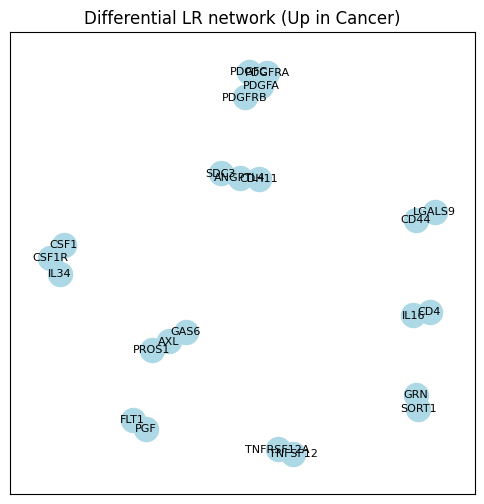

In [12]:

G = nx.from_pandas_edgelist(strong_diff, "ligand_symbol", "receptor_symbol", edge_attr="log2FC")
plt.figure(figsize=(6,6))
nx.draw_networkx(G, with_labels=True, node_color='lightblue', font_size=8)
plt.title("Differential LR network (Up in Cancer)")
plt.show()

## Method 2: Repurposed ScDisInfact Model for Differential CCC

### Setting up

In [13]:
for df in [normal_edges, cancer_edges]:
    df["sender_clean"]   = df["sender"].apply(clean_spot)
    df["receiver_clean"] = df["receiver"].apply(clean_spot)

In [14]:
for df in [normal_edges, cancer_edges]:
    df["edge_clean"] = (
        df["ligand"] + "|" +
        df["receptor"] 
    )


In [15]:
normal = set(normal_edges["edge_clean"])
cancer = set(cancer_edges["edge_clean"])

overlap = normal & cancer
unique_normal = normal - cancer
unique_cancer = cancer - normal

In [16]:
print("Normal edges:", len(normal_edges))
print("Cancer edges:", len(cancer_edges))
print("Overlap:", len(overlap))
print("Unique Normal:", len(unique_normal))
print("Unique Cancer:", len(unique_cancer))

Normal edges: 36850
Cancer edges: 548280
Overlap: 54
Unique Normal: 22
Unique Cancer: 126


In [17]:
df_normal = normal_edges[normal_edges["edge_clean"].isin(overlap)].copy()
df_cancer = cancer_edges[cancer_edges["edge_clean"].isin(overlap)].copy()

In [18]:
for df in [df_normal, df_cancer]:
    df["LR"] = df["ligand"].astype(str) + "__" + df["receptor"].astype(str)
    df["SR_Spot"] = df["sender_clean"].astype(str) + "__" + df["receiver_clean"].astype(str)

In [19]:
sender_norm = (
    df_normal
        .groupby(["SR_Spot", "LR"])["score"]
        .sum()
        .unstack(fill_value=0)
)

sender_canc = (
    df_cancer
        .groupby(["SR_Spot", "LR"])["score"]
        .sum()
        .unstack(fill_value=0)
)

In [20]:
all_LRs = sorted(
    set(sender_norm.columns) |
    set(sender_canc.columns) 
)

sender_norm   = sender_norm.reindex(columns=all_LRs, fill_value=0)
sender_canc   = sender_canc.reindex(columns=all_LRs, fill_value=0)
# receiver_norm = receiver_norm.reindex(columns=all_LRs, fill_value=0)
# receiver_canc = receiver_canc.reindex(columns=all_LRs, fill_value=0)

In [21]:
print("Sender matrix - normal:",   sender_norm.shape)
print("Sender matrix - cancer:",   sender_canc.shape)

Sender matrix - normal: (12276, 54)
Sender matrix - cancer: (60184, 54)


In [22]:
sender_norm["condition"] = "normal"
sender_canc["condition"] = "cancer"
sender_norm["batch"] = "normal_batch"
sender_canc["batch"] = "cancer_batch"


## Method 2A: Differential CCC without spatial features

In [23]:
combined_all = pd.concat([sender_norm, sender_canc], axis=0)

In [24]:
lr_cols = [c for c in combined_all.columns if c not in ["condition", "batch"]]
X = combined_all[lr_cols]

In [25]:
meta = combined_all[["condition", "batch"]]

In [26]:
data_dict = create_scdisinfact_dataset(X.values, meta, condition_key = ["condition"], batch_key = "batch")

Sanity check...
Finished.
Create scDisInFact datasets...
Finished.


In [27]:
# declare latent dimensions, we have two condition types, so there are three element corresponding to 
# shared-bio factor, unshared-bio factor for condition 1, unshared-bio factor for condition 2
Ks = [8, 2]
# training device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = scdisinfact(data_dict = data_dict, Ks = Ks, device = device)
losses = model.train_model(nepochs = 100)
_ = model.eval()

Epoch 0, Validating Loss: 0.8919
	 loss reconstruction: 0.02999
	 loss kl comm: 7.87606
	 loss kl diff: 2.05170
	 loss mmd common: 0.22971
	 loss mmd diff: 0.00006
	 loss classification: 0.49407
	 loss group lasso diff: 0.34723
GPU memory usage: 17.327637MB
Epoch 10, Validating Loss: 0.5367
	 loss reconstruction: 0.01978
	 loss kl comm: 32.66169
	 loss kl diff: 2.41520
	 loss mmd common: 0.39224
	 loss mmd diff: 0.00006
	 loss classification: 0.41296
	 loss group lasso diff: 0.07947
GPU memory usage: 17.327637MB
Epoch 20, Validating Loss: 0.5301
	 loss reconstruction: 0.01853
	 loss kl comm: 30.84487
	 loss kl diff: 2.08031
	 loss mmd common: 0.39786
	 loss mmd diff: 0.00006
	 loss classification: 0.41451
	 loss group lasso diff: 0.07596
GPU memory usage: 17.327637MB
Epoch 30, Validating Loss: 0.5086
	 loss reconstruction: 0.01797
	 loss kl comm: 28.52880
	 loss kl diff: 1.87907
	 loss mmd common: 0.39327
	 loss mmd diff: 0.00006
	 loss classification: 0.39735
	 loss group lasso diff: 

In [28]:
# one forward pass
z_cs = []
z_ds = []
zs = []

# loop through all training count matrices
for dataset in data_dict["datasets"]:
    with torch.no_grad():
        # pass through the encoders
        dict_inf = model.inference(counts = dataset.counts_norm.to(model.device), batch_ids = dataset.batch_id[:,None].to(model.device), print_stat = True)
        # pass through the decoder
        dict_gen = model.generative(z_c = dict_inf["mu_c"], z_d = dict_inf["mu_d"], batch_ids = dataset.batch_id[:,None].to(model.device))
        z_c = dict_inf["mu_c"]
        z_d = dict_inf["mu_d"]
        mu = dict_gen["mu"]    
        z_ds.append([x.cpu().detach().numpy() for x in z_d])
        z_cs.append(z_c.cpu().detach().numpy())

# shared-bio factor, concatenate across all training matrices
z_cs = np.concatenate(z_cs, axis = 0)
# unshared-bio factors for conditions 1 and 2
z_ds_cond1 = np.concatenate([x[0] for x in z_ds], axis = 0)

In [29]:
gene_scores = model.extract_gene_scores()
# scores for condition type 1
gene_scores[0]

array([0.03890562, 0.03129333, 0.13546471, 0.04069709, 0.03435564,
       0.03347379, 0.03858469, 0.03213444, 0.03554172, 0.0309734 ,
       0.033644  , 0.08844993, 0.06138325, 0.05715941, 0.04118221,
       0.05261873, 0.05410535, 0.4605851 , 0.0701035 , 0.08650023,
       0.07454513, 0.04895443, 0.02696123, 0.03506033, 0.03795723,
       0.03301947, 0.0420945 , 0.03361221, 0.03041674, 0.06340052,
       0.03179644, 0.03789425, 0.0305996 , 0.03552901, 0.03875551,
       0.02881623, 0.0366394 , 0.08811662, 0.07267613, 0.05585627,
       0.03589614, 0.04031137, 0.03179843, 0.05200454, 0.03451099,
       0.2984919 , 0.06061924, 0.02769059, 0.05442096, 0.06752266,
       0.02748072, 0.0380659 , 0.03639613, 0.12912144], dtype=float32)

In [30]:
important = pd.Series(gene_scores[0], index=X.columns)  # X.columns is your LR names
important = important.reset_index().rename(columns={"index": "LR"})
important["ligand_symbol"]   = important["LR"].apply(lambda x: "+".join(ensg_to_symbol(parse_lr(x)[0])))
important["receptor_symbol"] = important["LR"].apply(lambda x: "+".join(ensg_to_symbol(parse_lr(x)[1])))

important["LR_symbolic"] = important["ligand_symbol"] + " → " + important["receptor_symbol"]

In [31]:
important.sort_values(by = 0, ascending=False)

,LR,0,ligand_symbol,receptor_symbol,LR_symbolic
17,ENSG00000110492__ENSG00000115884,0.460585,MDK,SDC1,MDK → SDC1
45,ENSG00000168961__ENSG00000026508,0.298492,LGALS9,CD44,LGALS9 → CD44
2,ENSG00000030582__ENSG00000134243,0.135465,GRN,SORT1,GRN → SORT1
53,ENSG00000239697__ENSG00000006327,0.129121,TNFSF12,TNFRSF12A,TNFSF12 → TNFRSF12A
11,ENSG00000105835__ENSG00000161638_ENSG00000150093,0.088450,NAMPT,ITGA5+ITGB1,NAMPT → ITGA5+ITGB1
37,ENSG00000157368__ENSG00000182578,0.088117,IL34,CSF1R,IL34 → CSF1R
19,ENSG00000110492__ENSG00000124145,0.086500,MDK,SDC4,MDK → SDC4
20,ENSG00000110492__ENSG00000169439,0.074545,MDK,SDC2,MDK → SDC2
38,ENSG00000167772__ENSG00000115884,0.072676,ANGPTL4,SDC1,ANGPTL4 → SDC1
18,ENSG00000110492__ENSG00000123384,0.070104,MDK,LRP1,MDK → LRP1


In [32]:
z_ds_cond1

array([[-0.02141422,  0.0274106 ],
       [-0.01643527,  0.70178   ],
       [-0.01554019,  0.7758136 ],
       ...,
       [-0.0193857 , -0.70653856],
       [-0.03511551, -0.8630283 ],
       [-0.04657751, -1.0347825 ]], dtype=float32)

<Axes: xlabel='cond_dim_0', ylabel='cond_dim_1'>

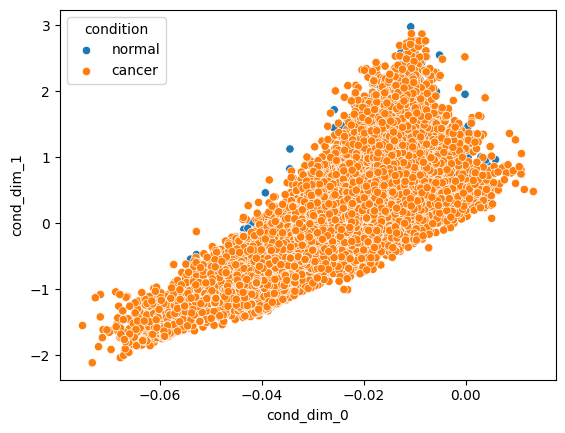

In [33]:
df_lat = pd.DataFrame(z_ds_cond1, columns=[f"cond_dim_{i}" for i in range(z_ds_cond1.shape[1])])
df_lat["condition"] = meta["condition"].values

sns.scatterplot(x="cond_dim_0", y="cond_dim_1", hue="condition", data=df_lat)

In [34]:
input_idx = ((meta["condition"] == "cancer") & (meta["batch"] == "cancer_batch")).values
counts_input = X.values[input_idx,:]
meta_input = meta.loc[input_idx,:]

counts_predict = model.predict_counts(input_counts = counts_input, meta_cells = meta_input, condition_keys = ["condition"], 
                                      batch_key = "batch", predict_conds = ["normal"], predict_batch = "normal_batch")


In [35]:
observed_cancer = X.values[input_idx, :54]

In [36]:
observed_cancer

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        2.55703727e-02, 2.00414798e-01, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 6.56067501e-05, ...,
        3.62293817e-02, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]])

In [37]:
lr_diff = observed_cancer - counts_predict[:,:54]
max_per_LR = np.max(lr_diff, axis=0)
max_LR_index = np.argmax(max_per_LR)
max_LR_value = max_per_LR[max_LR_index]
LR_names = X.columns   # 39 LR pairs
spots = X.index    # or combined_norm.index
max_spots = np.argmax(lr_diff, axis=0)

In [38]:
results = []

for j in range(lr_diff.shape[1]):   # for each LR feature
    row_idx = max_spots[j]
    sender_spot = spots[row_idx]
    lr_name = LR_names[j]
    max_value = max_per_LR[j]
    
    results.append((lr_name, sender_spot, max_value))

In [39]:
df_max = pd.DataFrame(results, columns=["LR_pair", "sender_spot", "max_LR_diff"])

In [40]:
# df_max["ligand_symbol"]   = df_max["LR_pair"].apply(lambda x: "+".join(ensg_to_symbol(parse_lr(x)[0])))
# df_max["receptor_symbol"] = df_max["LR_pair"].apply(lambda x: "+".join(ensg_to_symbol(parse_lr(x)[1])))
df_max["ligand_symbol"] = important["ligand_symbol"]
df_max["receptor_symbol"] = important["receptor_symbol"]
df_max["LR_symbolic"] = important["LR_symbolic"]

In [41]:
df_max

,LR_pair,sender_spot,max_LR_diff,ligand_symbol,receptor_symbol,LR_symbolic
0,ENSG00000017427__ENSG00000091409_ENSG00000132470,AGTAGCTAGACGCCGA-1__CTAAGTACAGGGCTAC-1,0.702298,IGF1,ITGA6+ITGB4,IGF1 → ITGA6+ITGB4
1,ENSG00000017427__ENSG00000140443,CCTATACCGTCCTGTC-1__TTGCGGCATCAGAAAG-1,0.637699,IGF1,IGF1R,IGF1 → IGF1R
2,ENSG00000030582__ENSG00000134243,TAGAATAGCCGATGAA-1__CTGCAGAGAATCAGAG-1,1.643006,GRN,SORT1,GRN → SORT1
3,ENSG00000075223__ENSG00000004399,CTGCACCTGGAACCGC-1__TGGAAGACGAACACCA-1,0.757330,SEMA3C,PLXND1,SEMA3C → PLXND1
4,ENSG00000075223__ENSG00000099250_ENSG00000114554,AGCTACGAATGGTGGT-1__CTGGGCTACTGGAGAG-1,0.602569,SEMA3C,NRP1+PLXNA1,SEMA3C → NRP1+PLXNA1
5,ENSG00000075223__ENSG00000099250_ENSG00000130827,GTAGCGGCTATACACT-1__GATCGTGACTGATATC-1,0.922859,SEMA3C,NRP1+PLXNA3,SEMA3C → NRP1+PLXNA3
6,ENSG00000100311__ENSG00000113721,CTAAAGTCCGAAGCTA-1__TTCAGAGTAACCTGAC-1,0.860362,PDGFB,PDGFRB,PDGFB → PDGFRB
7,ENSG00000100311__ENSG00000134853,AGTTGCGGTCCTCAAC-1__CGGGAAGTACCGTGGC-1,0.820648,PDGFB,PDGFRA,PDGFB → PDGFRA
8,ENSG00000105329__ENSG00000106799_ENSG00000163513,GCCACTCAGAGCGCGA-1__CCTGTTTGAAGACACG-1,0.600417,TGFB1,TGFBR1+TGFBR2,TGFB1 → TGFBR1+TGFBR2
9,ENSG00000105329__ENSG00000115170_ENSG000001067...,CTAGATTTACGACGGC-1__ACGCCGCTAGACGACC-1,0.470618,TGFB1,ACVR1+TGFBR1+TGFBR2,TGFB1 → ACVR1+TGFBR1+TGFBR2


In [42]:
sender_df = df_cancer[["sender_clean", "sender_celltype"]].rename(
    columns={"sender_clean": "spot", "sender_celltype": "celltype"}
)

# Build receiver spot–celltype pairs
receiver_df = df_cancer[["receiver_clean", "receiver_celltype"]].rename(
    columns={"receiver_clean": "spot", "receiver_celltype": "celltype"}
)

# Combine and drop duplicates
spot_celltype = (
    pd.concat([sender_df, receiver_df], axis=0)
      .drop_duplicates()
      .reset_index(drop=True)
)

spot_celltype

,spot,celltype
0,AAACAGTGTTCCTGGG-1,epithelial cell
1,AAACCGGAAATGTTAA-1,plasmablast
2,AAACGCTGGGCACGAC-1,epithelial cell
3,AAATGACTGATCAAAC-1,epithelial cell
4,AACAGCTGTGTGGCAA-1,plasmablast
...,...,...
4981,GGGTCATGCGTACCAT-1,plasmablast
4982,TGTGTCGAAGTCGAGG-1,plasmablast
4983,TTCAGTTTGTGGCAGC-1,B cell
4984,TCGCGTAGCAGTGTCC-1,B cell


In [43]:
# 1. Split sender_spot into sender_clean and receiver_clean
df_max[["sender_clean", "receiver_clean"]] = (
    df_max["sender_spot"].str.split("__", expand=True)
)

# 2. Create spot → celltype dictionary
spot2cell = dict(zip(spot_celltype["spot"], spot_celltype["celltype"]))

# 3. Map celltypes
df_max["sender_celltype"] = df_max["sender_clean"].map(spot2cell)
df_max["receiver_celltype"] = df_max["receiver_clean"].map(spot2cell)


In [44]:
df_max.sort_values(by = "max_LR_diff", ascending=False)

,LR_pair,sender_spot,max_LR_diff,ligand_symbol,receptor_symbol,LR_symbolic,sender_clean,receiver_clean,sender_celltype,receiver_celltype
45,ENSG00000168961__ENSG00000026508,CGTCAATCTTTAACAT-1__GGTCCTTCATACGACT-1,1.822299,LGALS9,CD44,LGALS9 → CD44,CGTCAATCTTTAACAT-1,GGTCCTTCATACGACT-1,endothelial cell,plasmablast
37,ENSG00000157368__ENSG00000182578,CGGGATCAATGTAAGA-1__CTCATTTGATGGGCGG-1,1.811151,IL34,CSF1R,IL34 → CSF1R,CGGGATCAATGTAAGA-1,CTCATTTGATGGGCGG-1,myeloid cell,epithelial cell
11,ENSG00000105835__ENSG00000161638_ENSG00000150093,CCTCGACCCACTGCCT-1__CCGACTCGCATAGTCT-1,1.712979,NAMPT,ITGA5+ITGB1,NAMPT → ITGA5+ITGB1,CCTCGACCCACTGCCT-1,CCGACTCGCATAGTCT-1,B cell,epithelial cell
46,ENSG00000172349__ENSG00000010610,CCATGCCCTAGATTTC-1__AATCATGTAAAGACTC-1,1.710548,IL16,CD4,IL16 → CD4,CCATGCCCTAGATTTC-1,AATCATGTAAAGACTC-1,epithelial cell,myeloid cell
2,ENSG00000030582__ENSG00000134243,TAGAATAGCCGATGAA-1__CTGCAGAGAATCAGAG-1,1.643006,GRN,SORT1,GRN → SORT1,TAGAATAGCCGATGAA-1,CTGCAGAGAATCAGAG-1,epithelial cell,epithelial cell
17,ENSG00000110492__ENSG00000115884,GCTACTATAGTAGAGT-1__TCCTTACGACGGTCCG-1,1.591570,MDK,SDC1,MDK → SDC1,GCTACTATAGTAGAGT-1,TCCTTACGACGGTCCG-1,epithelial cell,epithelial cell
12,ENSG00000105835__ENSG00000171105,CTATGAACACCTTGCC-1__TGGGTTTCGGGCGTAC-1,1.570909,NAMPT,INSR,NAMPT → INSR,CTATGAACACCTTGCC-1,TGGGTTTCGGGCGTAC-1,plasmablast,B cell
13,ENSG00000107562__ENSG00000121966,GAAACTCGTGCGATGC-1__TAGGTCCAAGTAAGGA-1,1.554362,CXCL12,CXCR4,CXCL12 → CXCR4,GAAACTCGTGCGATGC-1,TAGGTCCAAGTAAGGA-1,B cell,epithelial cell
18,ENSG00000110492__ENSG00000123384,GTAGCGGCTATACACT-1__GATCGTGACTGATATC-1,1.488763,MDK,LRP1,MDK → LRP1,GTAGCGGCTATACACT-1,GATCGTGACTGATATC-1,epithelial cell,plasmablast
20,ENSG00000110492__ENSG00000169439,CACTGACGATTGTGGA-1__TGAATGAGTGTTTCCC-1,1.480854,MDK,SDC2,MDK → SDC2,CACTGACGATTGTGGA-1,TGAATGAGTGTTTCCC-1,plasmablast,plasmablast


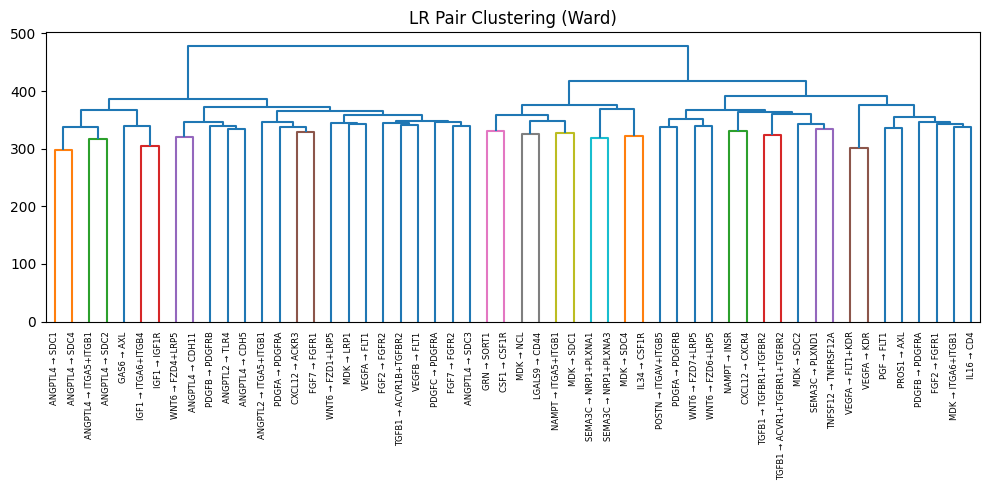

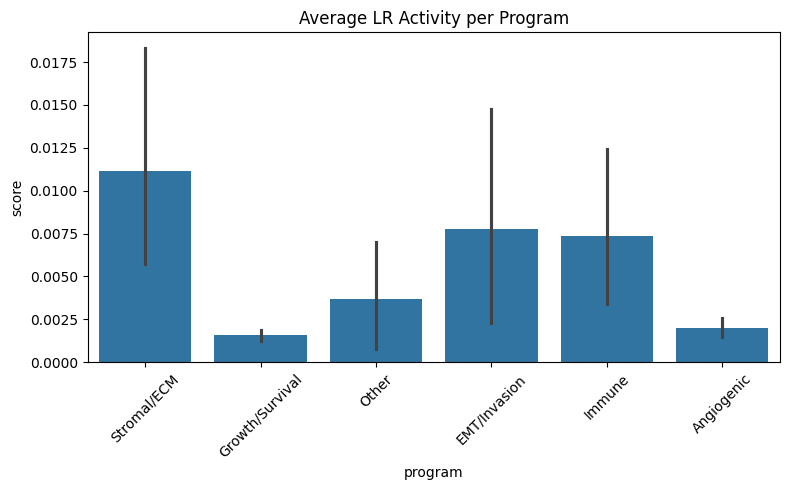

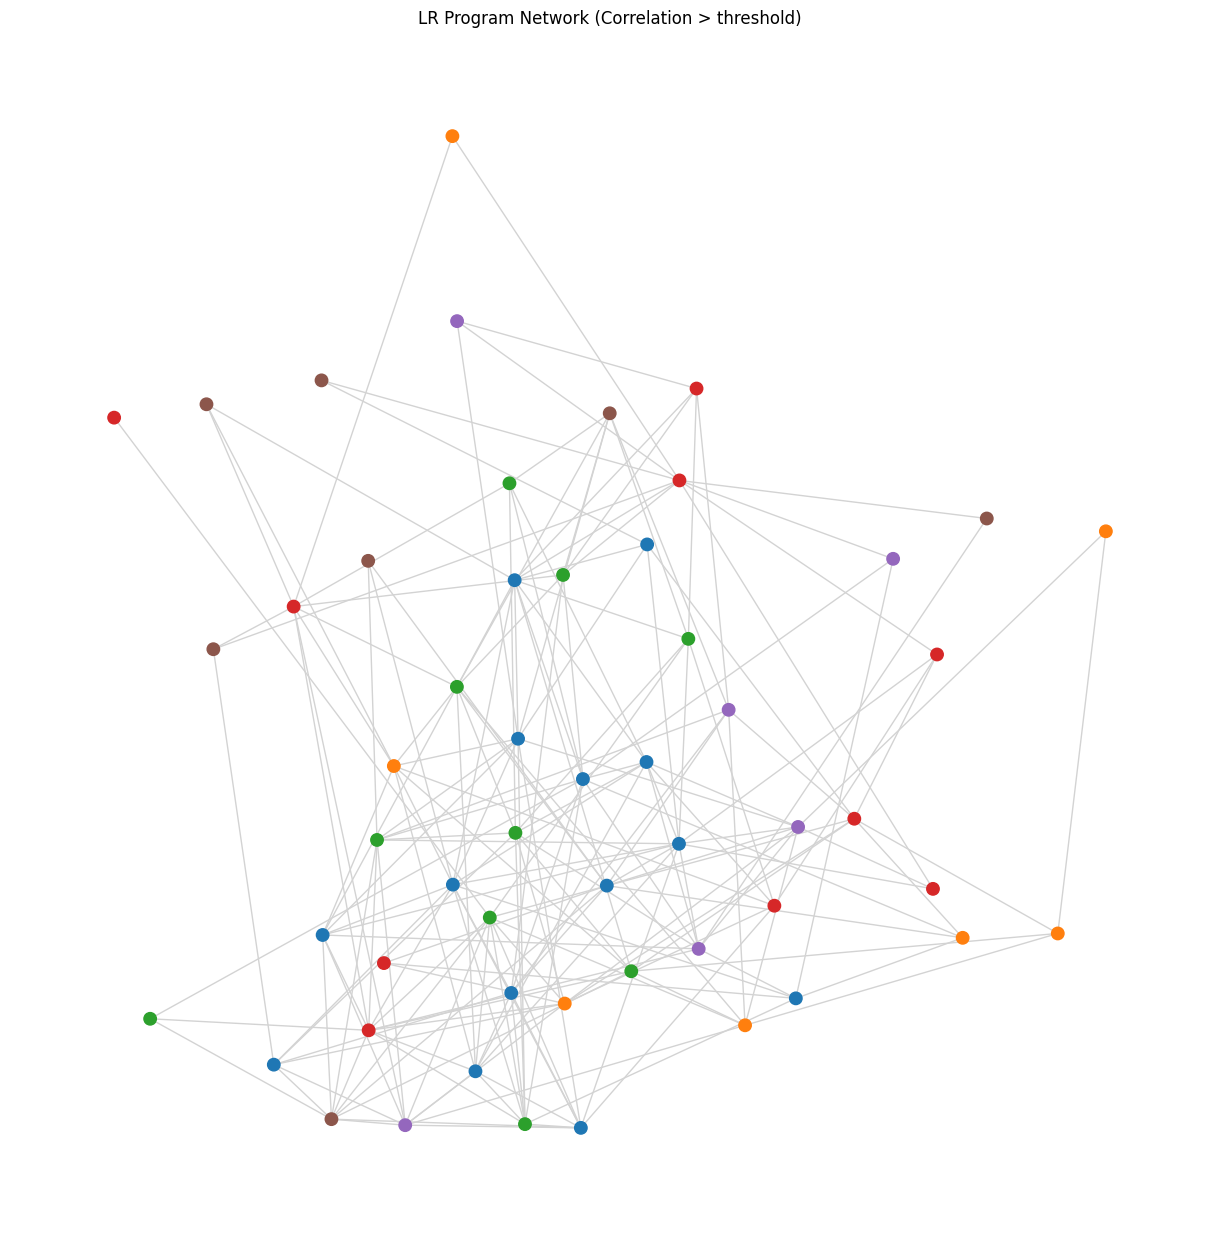

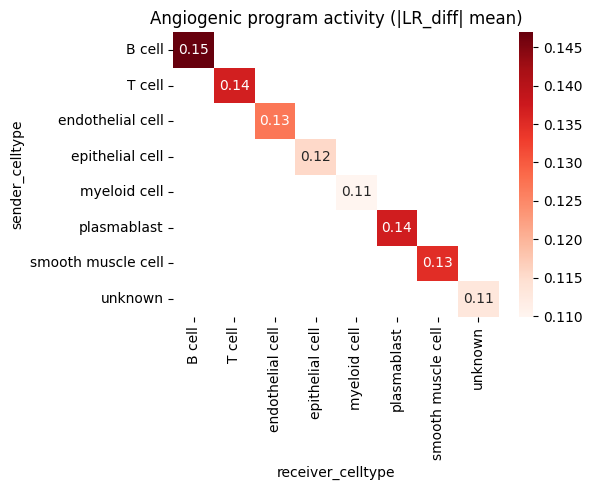

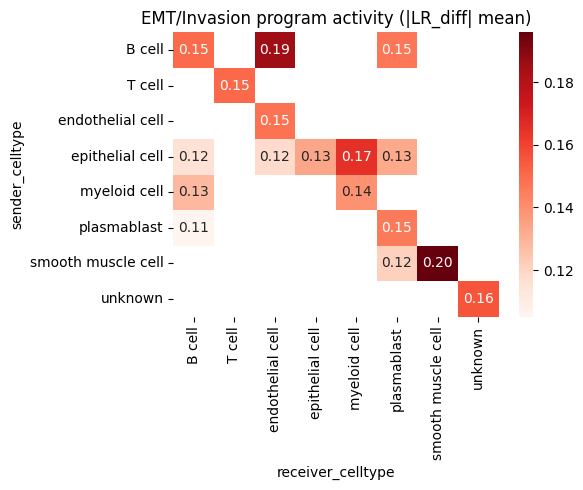

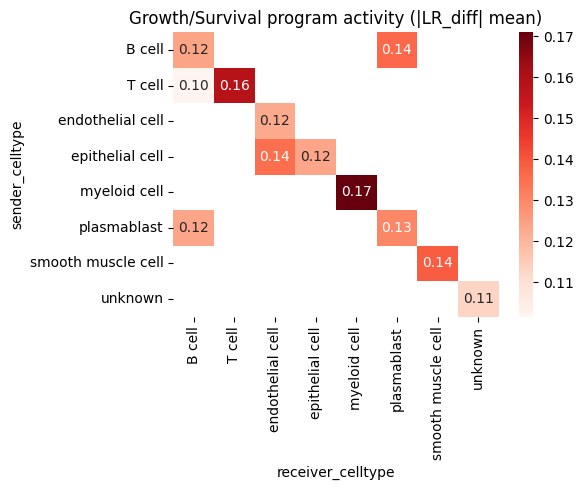

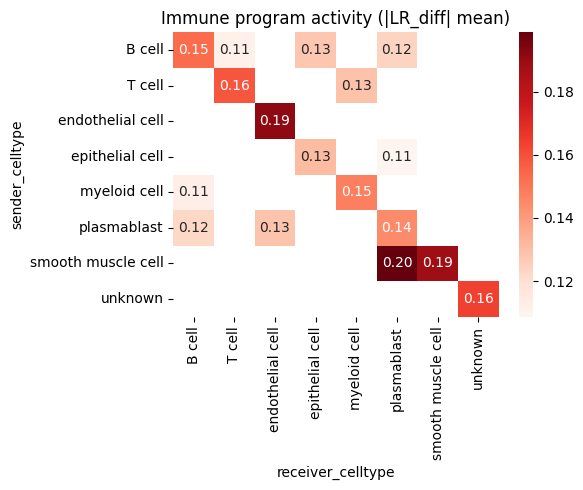

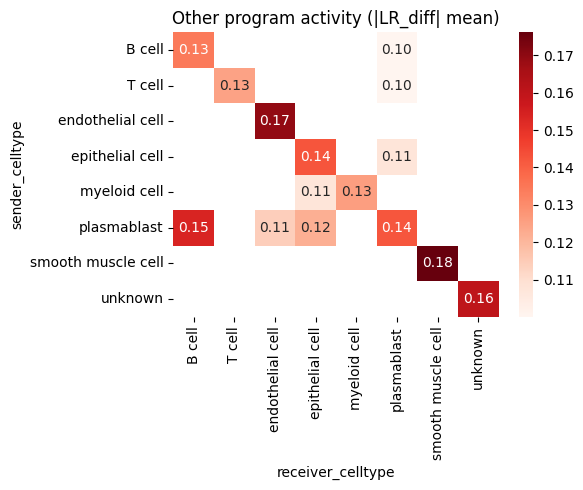

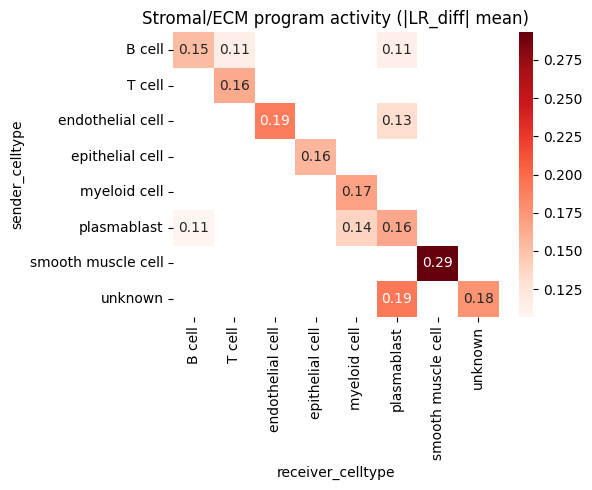

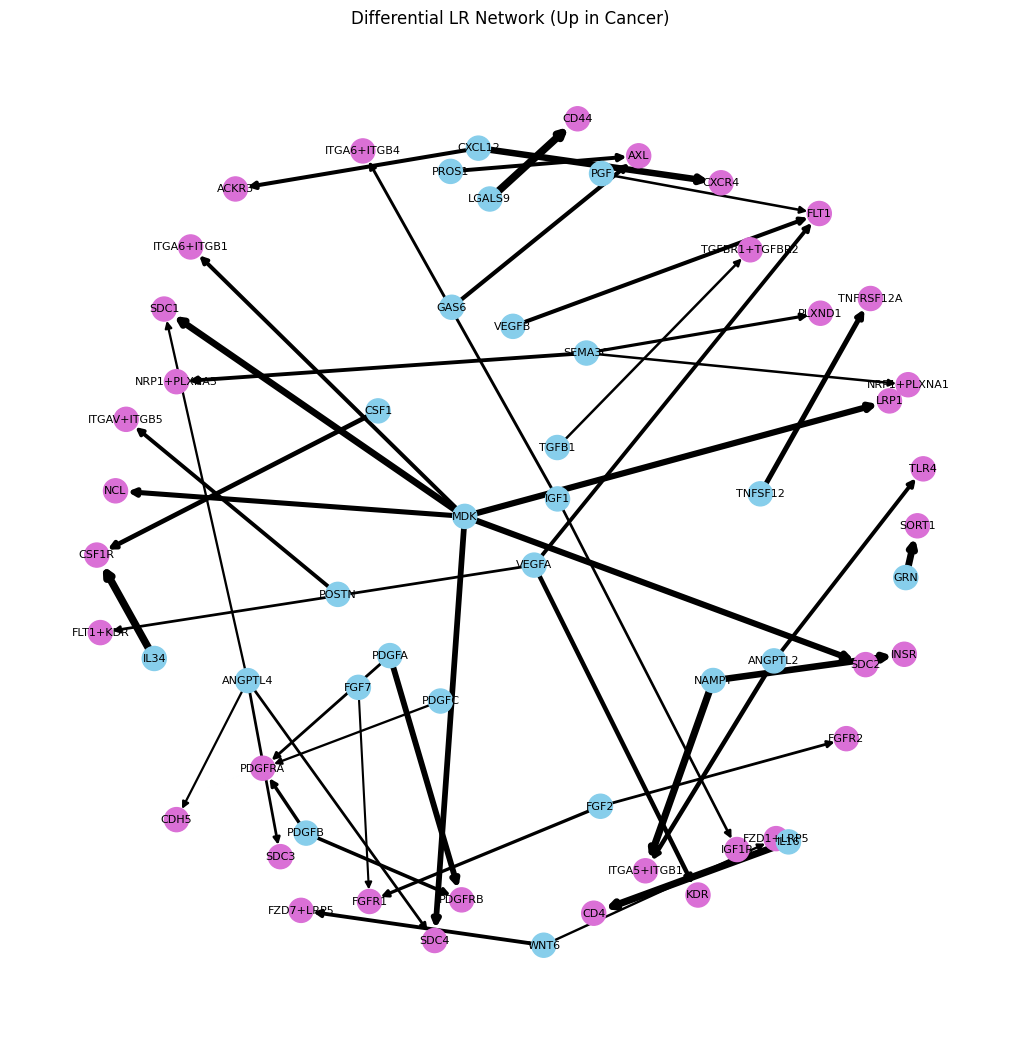

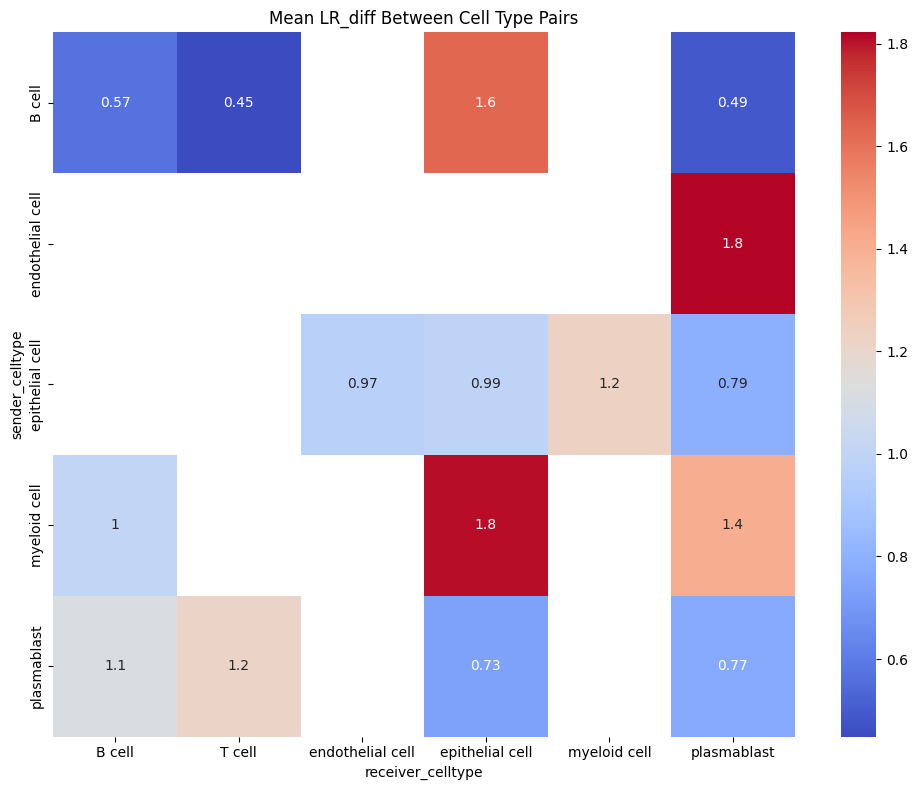

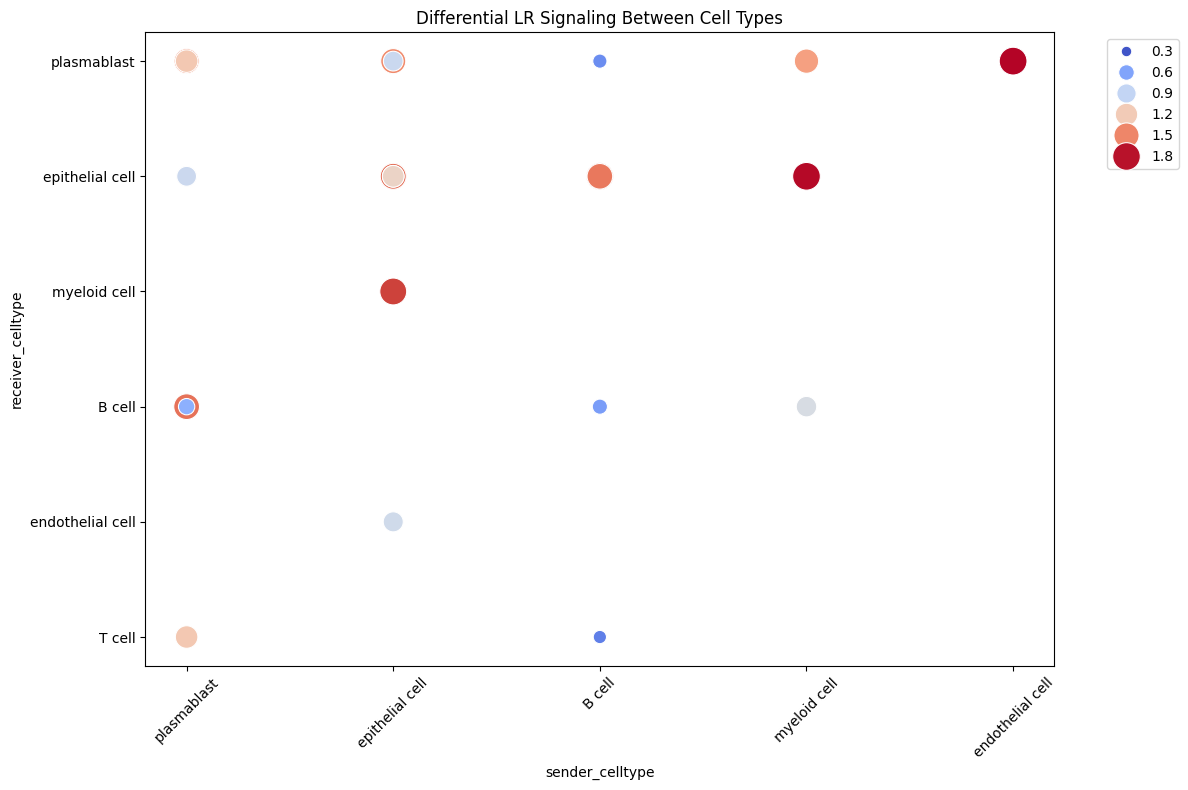

In [45]:
result = analyze_lr_programs(
    df_max=df_max,
    lr_diff=lr_diff,
    sender_canc=sender_canc,
    df_cancer=df_cancer
)

In [46]:
mdk_sdc1_cancer = sender_canc["ENSG00000110492__ENSG00000115884"]
mdk_sdc1_normal = sender_norm["ENSG00000110492__ENSG00000115884"]

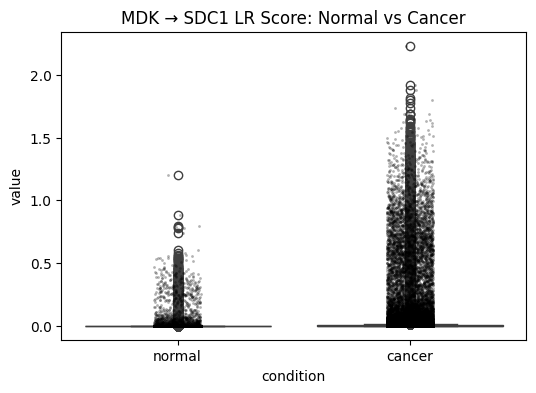

In [47]:
df_plot = pd.DataFrame({
    "value": pd.concat([mdk_sdc1_normal, mdk_sdc1_cancer], axis=0),
    "condition": ["normal"] * len(mdk_sdc1_normal) + ["cancer"] * len(mdk_sdc1_cancer)
})

plt.figure(figsize=(6,4))
sns.boxplot(data=df_plot, x="condition", y="value")
sns.stripplot(data=df_plot, x="condition", y="value", color="black", size=2, alpha=0.3)
plt.title("MDK → SDC1 LR Score: Normal vs Cancer")
plt.show()

In [48]:
lr_name = "ENSG00000110492__ENSG00000115884"
lr_index = list(sender_canc.columns).index(lr_name)
print("Column index:", lr_index)

Column index: 17


In [49]:
mdk_sdc1_obs  = observed_cancer[:, lr_index]
mdk_sdc1_pred = counts_predict[:, lr_index]

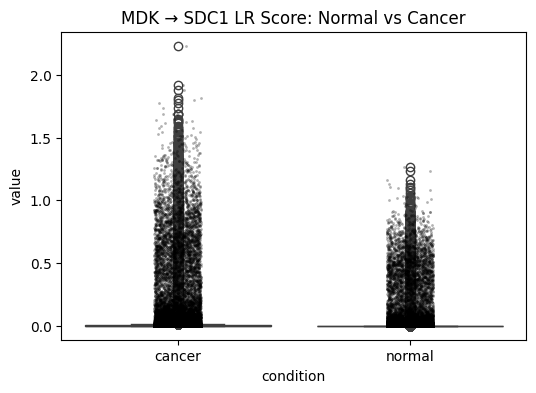

In [50]:
df_plot = pd.DataFrame({
    "value": pd.concat([
        pd.Series(mdk_sdc1_obs),
        pd.Series(mdk_sdc1_pred)
    ], axis=0),
    "condition": ["cancer"] * len(mdk_sdc1_obs) + ["normal"] * len(mdk_sdc1_pred)
})

plt.figure(figsize=(6,4))
sns.boxplot(data=df_plot, x="condition", y="value")
sns.stripplot(data=df_plot, x="condition", y="value", color="black", size=2, alpha=0.3)
plt.title("MDK → SDC1 LR Score: Normal vs Cancer")
plt.show()


## Method 2B: Differential CCC with Spatial Features

In [51]:
def compute_edge_features(
    df,
    sender_norm_or_canc,
    sender_x_col="sender_x",
    sender_y_col="sender_y",
    receiver_x_col="receiver_x",
    receiver_y_col="receiver_y",
    score_col="score",
    sr_col="SR_Spot",
    sender_clean_col="sender_clean",
    receiver_clean_col="receiver_clean",
    k_neighbors=10
):
    # --------------------------------------------
    # 1. Edge distance
    # --------------------------------------------
    sx = df[sender_x_col].values
    sy = df[sender_y_col].values
    rx = df[receiver_x_col].values
    ry = df[receiver_y_col].values

    edge_distance = np.sqrt((sx - rx)**2 + (sy - ry)**2)
    edge_log_distance = np.log1p(edge_distance)

    # --------------------------------------------
    # 2. Build spot table (deduplicated)
    # --------------------------------------------
    all_spots = pd.concat([df[sender_clean_col], df[receiver_clean_col]]).unique()

    sender_coords = df.groupby(sender_clean_col)[[sender_x_col, sender_y_col]].first()
    receiver_coords = df.groupby(receiver_clean_col)[[receiver_x_col, receiver_y_col]].first()

    spot_df = pd.DataFrame(index=all_spots, columns=["x", "y"], dtype=float)
    spot_df.loc[sender_coords.index] = sender_coords.values
    spot_df.loc[receiver_coords.index] = receiver_coords.values
    spot_df = spot_df.dropna()

    coords = spot_df[["x", "y"]].values

    # --------------------------------------------
    # 3. KNN
    # --------------------------------------------
    nn = NearestNeighbors(n_neighbors=min(k_neighbors, len(coords)))
    nn.fit(coords)
    _, indices = nn.kneighbors(coords)

    # --------------------------------------------
    # 4. Spot LR aggregation
    # --------------------------------------------
    spot_to_scores = {sp: [] for sp in spot_df.index}

    for idx, row in df.iterrows():
        spot_to_scores[row[sender_clean_col]].append(row[score_col])
        spot_to_scores[row[receiver_clean_col]].append(row[score_col])

    base_LR = np.array([
        np.mean(spot_to_scores[sp]) if len(spot_to_scores[sp]) else 0.0
        for sp in spot_df.index
    ])

    hotspot = np.array([
        np.mean(base_LR[n]) for n in indices
    ])

    spot_df["spot_hotspot"] = hotspot
    hot_map = spot_df["spot_hotspot"].to_dict()

    sender_hot = df[sender_clean_col].map(hot_map).values
    receiver_hot = df[receiver_clean_col].map(hot_map).values
    edge_hot_mean = (sender_hot + receiver_hot) / 2.0

    # --------------------------------------------
    # 5. Feature DF (dedupe index before joining)
    # --------------------------------------------
    feature_df = pd.DataFrame({
        "SR_Spot": df[sr_col].values,
        "edge_distance": edge_distance,
        "edge_log_distance": edge_log_distance,
        "sender_hotspot": sender_hot,
        "receiver_hotspot": receiver_hot,
        "edge_hotspot_mean": edge_hot_mean
    })

    # IMPORTANT: dedupe index
    feature_df = feature_df.drop_duplicates(subset="SR_Spot", keep="first")
    feature_df = feature_df.set_index("SR_Spot")

    # Now safely use .loc even if sender_norm index has duplicates
    return feature_df.loc[sender_norm_or_canc.index]


In [52]:
edge_features_normal = compute_edge_features(
    df_normal,
    sender_norm
)

sender_norm = pd.concat([sender_norm, edge_features_normal], axis=1)

In [53]:
edge_features_cancer = compute_edge_features(
    df_cancer,
    sender_canc
)

sender_canc = pd.concat([sender_canc, edge_features_cancer], axis=1)

In [54]:
combined_all = pd.concat([sender_norm, sender_canc], axis=0)
lr_cols = [c for c in combined_all.columns if c not in ["condition", "batch", "edge_distance", "sender_hotspot", "receiver_hotspot", "edge_log_distance"]]
X = combined_all[lr_cols]
meta = combined_all[["condition", "batch"]]

In [55]:
np.min(combined_all["edge_hotspot_mean"])

0.044821411714876414

In [56]:
from scDisInFact import scdisinfact, create_scdisinfact_dataset
data_dict = create_scdisinfact_dataset(X.values, meta, condition_key = ["condition"], batch_key = "batch")

Sanity check...
Finished.
Create scDisInFact datasets...
Finished.


In [57]:
Ks = [8, 2]
# training device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_sp = scdisinfact(data_dict = data_dict, Ks = Ks, device = device)
losses = model_sp.train_model(nepochs = 100)
_ = model_sp.eval()

Epoch 0, Validating Loss: 0.8610
	 loss reconstruction: 0.03776
	 loss kl comm: 8.56558
	 loss kl diff: 1.85461
	 loss mmd common: 0.33851
	 loss mmd diff: 0.00006
	 loss classification: 0.60622
	 loss group lasso diff: 0.19835
GPU memory usage: 27.827637MB
Epoch 10, Validating Loss: 0.6061
	 loss reconstruction: 0.02599
	 loss kl comm: 28.81519
	 loss kl diff: 2.62930
	 loss mmd common: 0.30863
	 loss mmd diff: 0.00006
	 loss classification: 0.46201
	 loss group lasso diff: 0.09151
GPU memory usage: 27.827637MB
Epoch 20, Validating Loss: 0.5683
	 loss reconstruction: 0.02472
	 loss kl comm: 27.73671
	 loss kl diff: 2.62641
	 loss mmd common: 0.32285
	 loss mmd diff: 0.00006
	 loss classification: 0.42553
	 loss group lasso diff: 0.09149
GPU memory usage: 27.827637MB
Epoch 30, Validating Loss: 0.5713
	 loss reconstruction: 0.02412
	 loss kl comm: 26.94126
	 loss kl diff: 2.77819
	 loss mmd common: 0.33343
	 loss mmd diff: 0.00006
	 loss classification: 0.42800
	 loss group lasso diff: 

In [58]:
# one forward pass
z_cs = []
z_ds = []
zs = []

# loop through all training count matrices
for dataset in data_dict["datasets"]:
    with torch.no_grad():
        # pass through the encoders
        dict_inf = model_sp.inference(counts = dataset.counts_norm.to(model_sp.device), batch_ids = dataset.batch_id[:,None].to(model_sp.device), print_stat = True)
        # pass through the decoder
        dict_gen = model_sp.generative(z_c = dict_inf["mu_c"], z_d = dict_inf["mu_d"], batch_ids = dataset.batch_id[:,None].to(model_sp.device))
        z_c = dict_inf["mu_c"]
        z_d = dict_inf["mu_d"]
        mu = dict_gen["mu"]    
        z_ds.append([x.cpu().detach().numpy() for x in z_d])
        z_cs.append(z_c.cpu().detach().numpy())

# shared-bio factor, concatenate across all training matrices
z_cs = np.concatenate(z_cs, axis = 0)
# unshared-bio factors for conditions 1 and 2
z_ds_cond1 = np.concatenate([x[0] for x in z_ds], axis = 0)

In [59]:
z_ds_cond1

array([[-0.10494193, -0.42829937],
       [-0.20582068, -0.90789455],
       [-0.1788269 , -0.76503575],
       ...,
       [ 0.11833435,  0.17612861],
       [ 0.38469765,  0.64666975],
       [ 0.25171262,  0.52596426]], dtype=float32)

In [60]:
gene_scores = model_sp.extract_gene_scores()
# scores for condition type 1
gene_scores[0]

array([0.02860452, 0.0347073 , 0.22224857, 0.04950456, 0.02512795,
       0.03890773, 0.03987482, 0.0301917 , 0.04151778, 0.04636892,
       0.03614116, 0.10303199, 0.08682573, 0.05205829, 0.05081248,
       0.05365146, 0.0689052 , 0.57304543, 0.07656815, 0.09795426,
       0.07842883, 0.05164757, 0.02320117, 0.04158655, 0.02670755,
       0.03551676, 0.03474435, 0.03265746, 0.04194003, 0.06713592,
       0.03713068, 0.04575158, 0.03431357, 0.03347751, 0.03394548,
       0.03369703, 0.03067617, 0.08911544, 0.05837534, 0.05939914,
       0.04316936, 0.0414051 , 0.03952237, 0.04238449, 0.04175785,
       0.3934055 , 0.07944796, 0.03489893, 0.06168114, 0.07535619,
       0.03171017, 0.03486326, 0.03762843, 0.15225849, 0.49450696],
      dtype=float32)

In [61]:
gene_scores[0]

array([0.02860452, 0.0347073 , 0.22224857, 0.04950456, 0.02512795,
       0.03890773, 0.03987482, 0.0301917 , 0.04151778, 0.04636892,
       0.03614116, 0.10303199, 0.08682573, 0.05205829, 0.05081248,
       0.05365146, 0.0689052 , 0.57304543, 0.07656815, 0.09795426,
       0.07842883, 0.05164757, 0.02320117, 0.04158655, 0.02670755,
       0.03551676, 0.03474435, 0.03265746, 0.04194003, 0.06713592,
       0.03713068, 0.04575158, 0.03431357, 0.03347751, 0.03394548,
       0.03369703, 0.03067617, 0.08911544, 0.05837534, 0.05939914,
       0.04316936, 0.0414051 , 0.03952237, 0.04238449, 0.04175785,
       0.3934055 , 0.07944796, 0.03489893, 0.06168114, 0.07535619,
       0.03171017, 0.03486326, 0.03762843, 0.15225849, 0.49450696],
      dtype=float32)

In [62]:
important_s = pd.Series(gene_scores[0], index=X.columns)  # X.columns is your LR names

In [63]:
important_s = important_s[:54]

In [64]:
important_s

ENSG00000017427__ENSG00000091409_ENSG00000132470                    0.028605
ENSG00000017427__ENSG00000140443                                    0.034707
ENSG00000030582__ENSG00000134243                                    0.222249
ENSG00000075223__ENSG00000004399                                    0.049505
ENSG00000075223__ENSG00000099250_ENSG00000114554                    0.025128
ENSG00000075223__ENSG00000099250_ENSG00000130827                    0.038908
ENSG00000100311__ENSG00000113721                                    0.039875
ENSG00000100311__ENSG00000134853                                    0.030192
ENSG00000105329__ENSG00000106799_ENSG00000163513                    0.041518
ENSG00000105329__ENSG00000115170_ENSG00000106799_ENSG00000163513    0.046369
ENSG00000105329__ENSG00000135503_ENSG00000163513                    0.036141
ENSG00000105835__ENSG00000161638_ENSG00000150093                    0.103032
ENSG00000105835__ENSG00000171105                                    0.086826

In [65]:
important_s = important_s.reset_index().rename(columns={"index": "LR"})


In [66]:
important_s["ligand_symbol"]   = important["ligand_symbol"]
important_s["receptor_symbol"] = important["receptor_symbol"]

important_s["LR_symbolic"] = important["LR_symbolic"]

In [67]:
important_s.sort_values(by = 0, ascending=False)

,LR,0,ligand_symbol,receptor_symbol,LR_symbolic
17,ENSG00000110492__ENSG00000115884,0.573045,MDK,SDC1,MDK → SDC1
45,ENSG00000168961__ENSG00000026508,0.393405,LGALS9,CD44,LGALS9 → CD44
2,ENSG00000030582__ENSG00000134243,0.222249,GRN,SORT1,GRN → SORT1
53,ENSG00000239697__ENSG00000006327,0.152258,TNFSF12,TNFRSF12A,TNFSF12 → TNFRSF12A
11,ENSG00000105835__ENSG00000161638_ENSG00000150093,0.103032,NAMPT,ITGA5+ITGB1,NAMPT → ITGA5+ITGB1
19,ENSG00000110492__ENSG00000124145,0.097954,MDK,SDC4,MDK → SDC4
37,ENSG00000157368__ENSG00000182578,0.089115,IL34,CSF1R,IL34 → CSF1R
12,ENSG00000105835__ENSG00000171105,0.086826,NAMPT,INSR,NAMPT → INSR
46,ENSG00000172349__ENSG00000010610,0.079448,IL16,CD4,IL16 → CD4
20,ENSG00000110492__ENSG00000169439,0.078429,MDK,SDC2,MDK → SDC2


<Axes: xlabel='cond_dim_0', ylabel='cond_dim_1'>

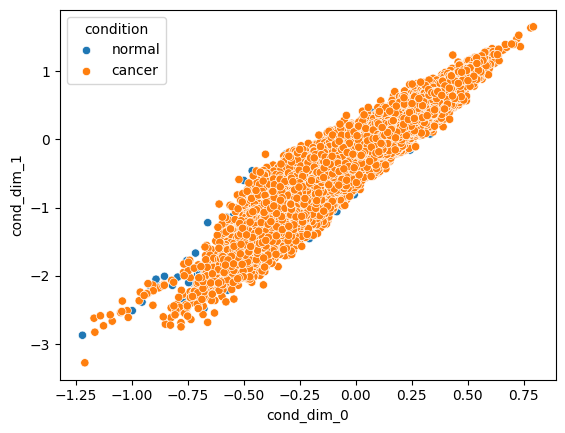

In [68]:
df_lat = pd.DataFrame(z_ds_cond1, columns=[f"cond_dim_{i}" for i in range(z_ds_cond1.shape[1])])
df_lat["condition"] = meta["condition"].values

sns.scatterplot(x="cond_dim_0", y="cond_dim_1", hue="condition", data=df_lat)

In [69]:
input_idx = ((meta["condition"] == "cancer") & (meta["batch"] == "cancer_batch")).values
counts_input = X.values[input_idx,:]
meta_input = meta.loc[input_idx,:]

counts_predict = model_sp.predict_counts(input_counts = counts_input, meta_cells = meta_input, condition_keys = ["condition"], 
                                      batch_key = "batch", predict_conds = ["normal"], predict_batch = "normal_batch")


In [70]:
observed_cancer = X.values[input_idx, :54]
lr_diff = observed_cancer - counts_predict[:,:54]

max_per_LR = np.max(np.abs(lr_diff), axis=0)
max_LR_index = np.argmax(max_per_LR)
max_LR_value = max_per_LR[max_LR_index]
LR_names = X.columns   # 39 LR pairs
spots = X.index    # or combined_norm.index
max_spots = np.argmax(lr_diff, axis=0)

In [71]:
lr_diff

array([[ 0.00000000e+00,  0.00000000e+00, -2.47131760e-41, ...,
         0.00000000e+00,  0.00000000e+00, -9.66527362e-20],
       [-3.03277728e-48, -3.50198407e-19,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00, -7.07296237e-19, ...,
         0.00000000e+00,  0.00000000e+00, -4.38216463e-41],
       ...,
       [-4.51017253e-06, -1.25486330e-17, -1.36644930e-09, ...,
        -3.48278701e-02,  1.12601902e-01, -1.21100885e-06],
       [-2.32545685e-24, -5.18346454e-44,  6.56067501e-05, ...,
         6.55135286e-03, -1.25238821e-02, -8.04324542e-11],
       [-3.98725543e-05, -3.00209456e-06, -7.39808421e-02, ...,
        -3.21312173e-06, -1.38022515e-07, -1.21581837e-04]])

In [72]:
results = []

for j in range(lr_diff.shape[1]):   # for each LR feature
    row_idx = max_spots[j]
    sender_spot = spots[row_idx]
    lr_name = LR_names[j]
    max_value = max_per_LR[j]
    
    results.append((lr_name, sender_spot, max_value))

In [73]:
df_max = pd.DataFrame(results, columns=["LR_pair", "receiver_spot", "max_LR_diff"])

In [74]:
df_max["ligand_symbol"]   = important["ligand_symbol"]
df_max["receptor_symbol"] = important["receptor_symbol"]
df_max["LR_symbolic"] = important["LR_symbolic"]

In [75]:
lr_name = "ENSG00000167772__ENSG00000140937"
lr_index = list(sender_canc.columns).index(lr_name)
print("Column index:", lr_index)

Column index: 40


In [76]:
mdk_sdc1_obs  = observed_cancer[:, lr_index]
mdk_sdc1_pred = counts_predict[:, lr_index]

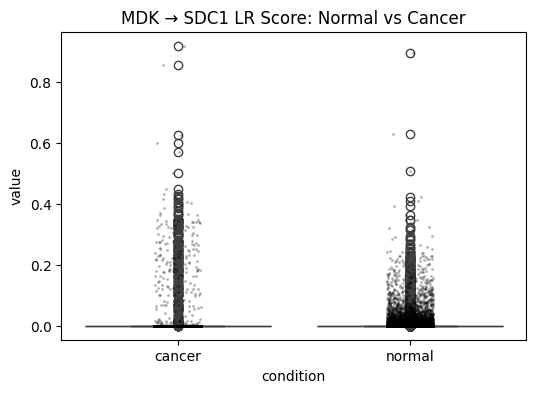

In [77]:
df_plot = pd.DataFrame({
    "value": pd.concat([
        pd.Series(mdk_sdc1_obs),
        pd.Series(mdk_sdc1_pred)
    ], axis=0),
    "condition": ["cancer"] * len(mdk_sdc1_obs) + ["normal"] * len(mdk_sdc1_pred)
})

plt.figure(figsize=(6,4))
sns.boxplot(data=df_plot, x="condition", y="value")
sns.stripplot(data=df_plot, x="condition", y="value", color="black", size=2, alpha=0.3)
plt.title("MDK → SDC1 LR Score: Normal vs Cancer")
plt.show()


In [78]:
# 1. Split sender_spot into sender_clean and receiver_clean
df_max[["sender_clean", "receiver_clean"]] = (
    df_max["receiver_spot"].str.split("__", expand=True)
)

# 2. Create spot → celltype dictionary
spot2cell = dict(zip(spot_celltype["spot"], spot_celltype["celltype"]))

# 3. Map celltypes
df_max["sender_celltype"] = df_max["sender_clean"].map(spot2cell)
df_max["receiver_celltype"] = df_max["receiver_clean"].map(spot2cell)

In [80]:
df_max.sort_values(by = "max_LR_diff", ascending=False)

,LR_pair,receiver_spot,max_LR_diff,ligand_symbol,receptor_symbol,LR_symbolic,sender_clean,receiver_clean,sender_celltype,receiver_celltype
11,ENSG00000105835__ENSG00000161638_ENSG00000150093,CCTCGACCCACTGCCT-1__CCGACTCGCATAGTCT-1,1.705827,NAMPT,ITGA5+ITGB1,NAMPT → ITGA5+ITGB1,CCTCGACCCACTGCCT-1,CCGACTCGCATAGTCT-1,B cell,epithelial cell
17,ENSG00000110492__ENSG00000115884,CCGCCGGTCAACACAC-1__AGGCCCATTGTACAGG-1,1.667396,MDK,SDC1,MDK → SDC1,CCGCCGGTCAACACAC-1,AGGCCCATTGTACAGG-1,plasmablast,epithelial cell
18,ENSG00000110492__ENSG00000123384,GTAGCGGCTATACACT-1__GATCGTGACTGATATC-1,1.554424,MDK,LRP1,MDK → LRP1,GTAGCGGCTATACACT-1,GATCGTGACTGATATC-1,epithelial cell,plasmablast
2,ENSG00000030582__ENSG00000134243,CCCGTTTCGCAGATGT-1__CCCGTTTCGCAGATGT-1,1.470129,GRN,SORT1,GRN → SORT1,CCCGTTTCGCAGATGT-1,CCCGTTTCGCAGATGT-1,epithelial cell,epithelial cell
46,ENSG00000172349__ENSG00000010610,ATCAATGCCGTGGCTG-1__AAACACCAATAACTGC-1,1.436900,IL16,CD4,IL16 → CD4,ATCAATGCCGTGGCTG-1,AAACACCAATAACTGC-1,plasmablast,plasmablast
45,ENSG00000168961__ENSG00000026508,CTGGGTTGAGTTAAAG-1__TCTAAAGAACAGTCTC-1,1.427091,LGALS9,CD44,LGALS9 → CD44,CTGGGTTGAGTTAAAG-1,TCTAAAGAACAGTCTC-1,plasmablast,plasmablast
20,ENSG00000110492__ENSG00000169439,GGTTACCGCTCCCTAC-1__TTCCAGTGGGTTTCGT-1,1.407348,MDK,SDC2,MDK → SDC2,GGTTACCGCTCCCTAC-1,TTCCAGTGGGTTTCGT-1,plasmablast,plasmablast
51,ENSG00000197461__ENSG00000113721,CCTCGACCCACTGCCT-1__CCGACTCGCATAGTCT-1,1.309897,PDGFA,PDGFRB,PDGFA → PDGFRB,CCTCGACCCACTGCCT-1,CCGACTCGCATAGTCT-1,B cell,epithelial cell
19,ENSG00000110492__ENSG00000124145,AATATCCTAGCAAACT-1__GAGTCTTGTAAAGGAC-1,1.282476,MDK,SDC4,MDK → SDC4,AATATCCTAGCAAACT-1,GAGTCTTGTAAAGGAC-1,plasmablast,plasmablast
37,ENSG00000157368__ENSG00000182578,ATAGAGTTATCAACTT-1__AAATTACCTATCGATG-1,1.271828,IL34,CSF1R,IL34 → CSF1R,ATAGAGTTATCAACTT-1,AAATTACCTATCGATG-1,smooth muscle cell,myeloid cell


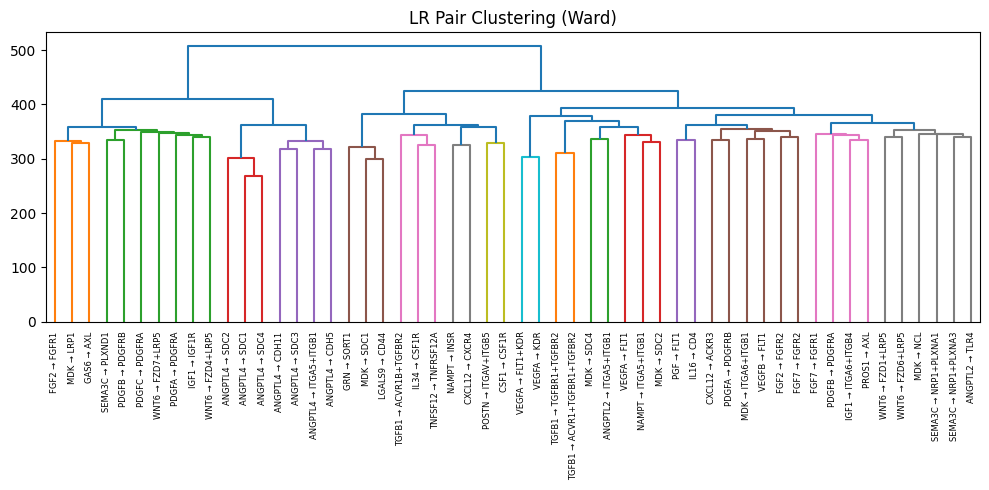

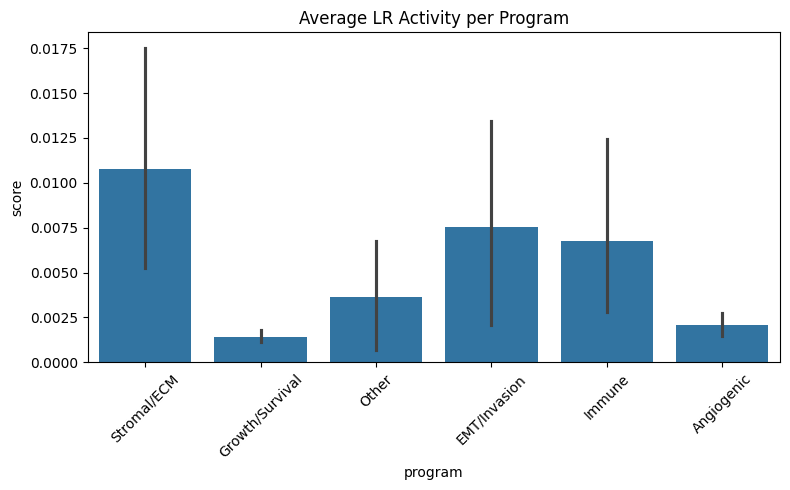

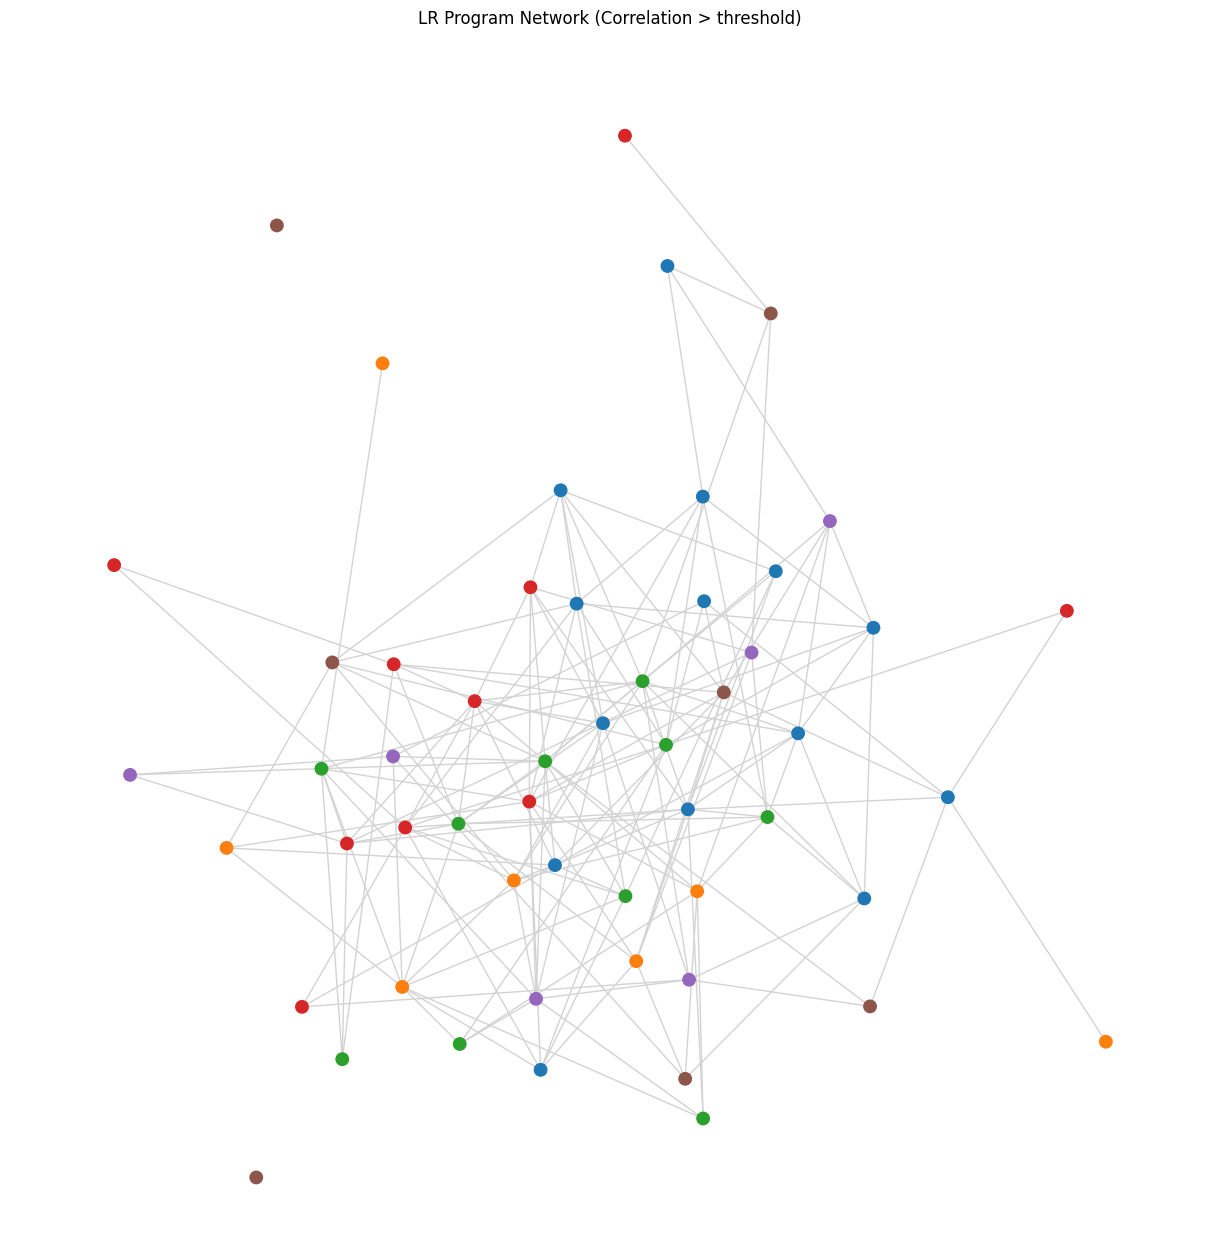

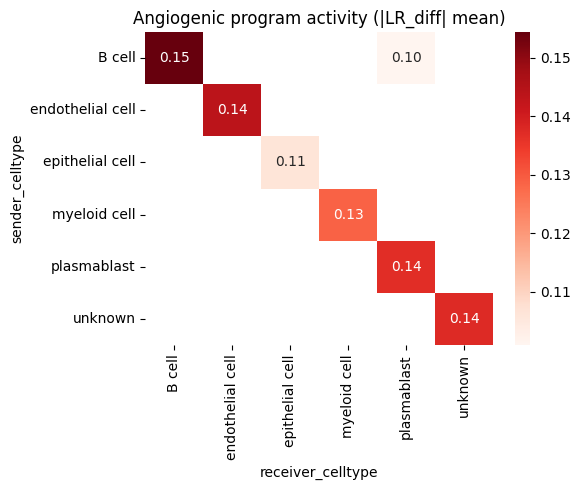

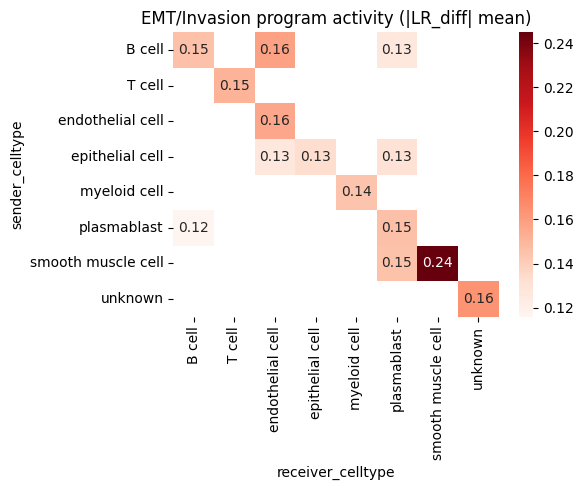

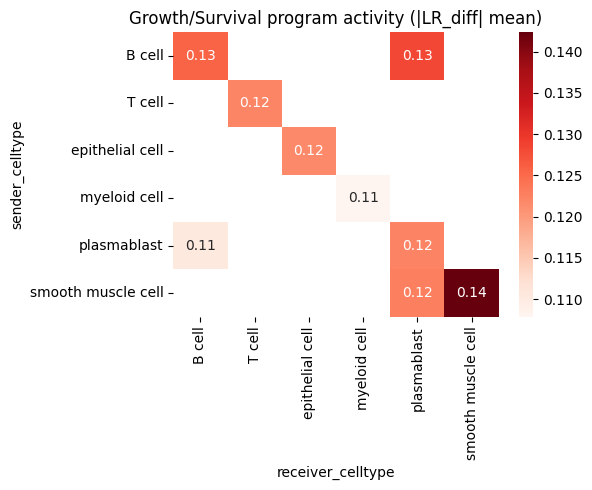

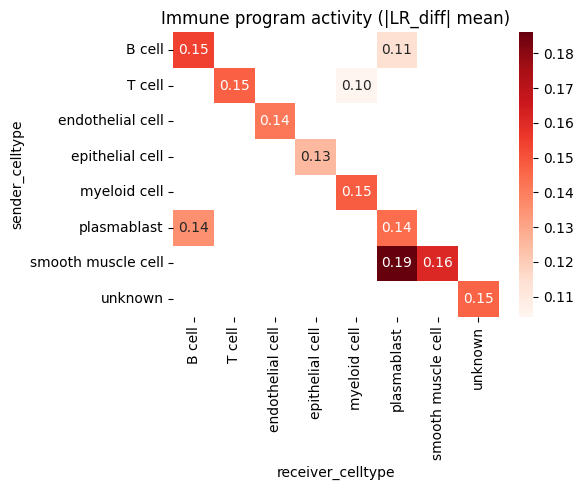

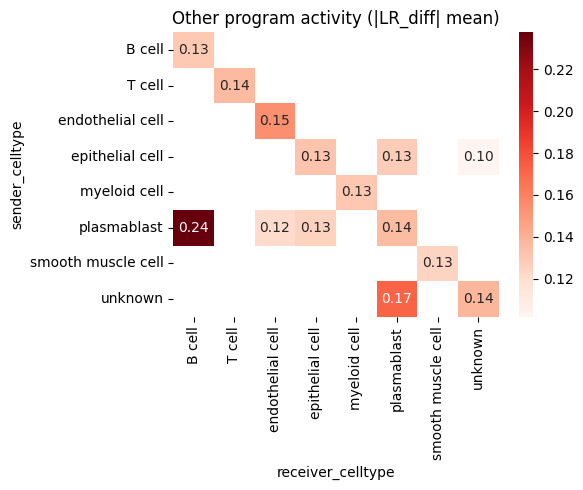

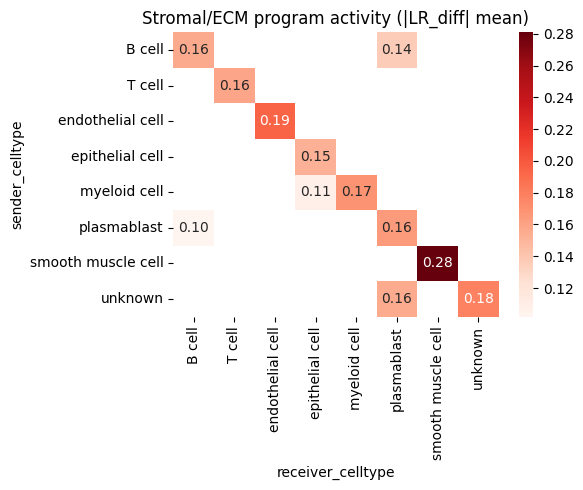

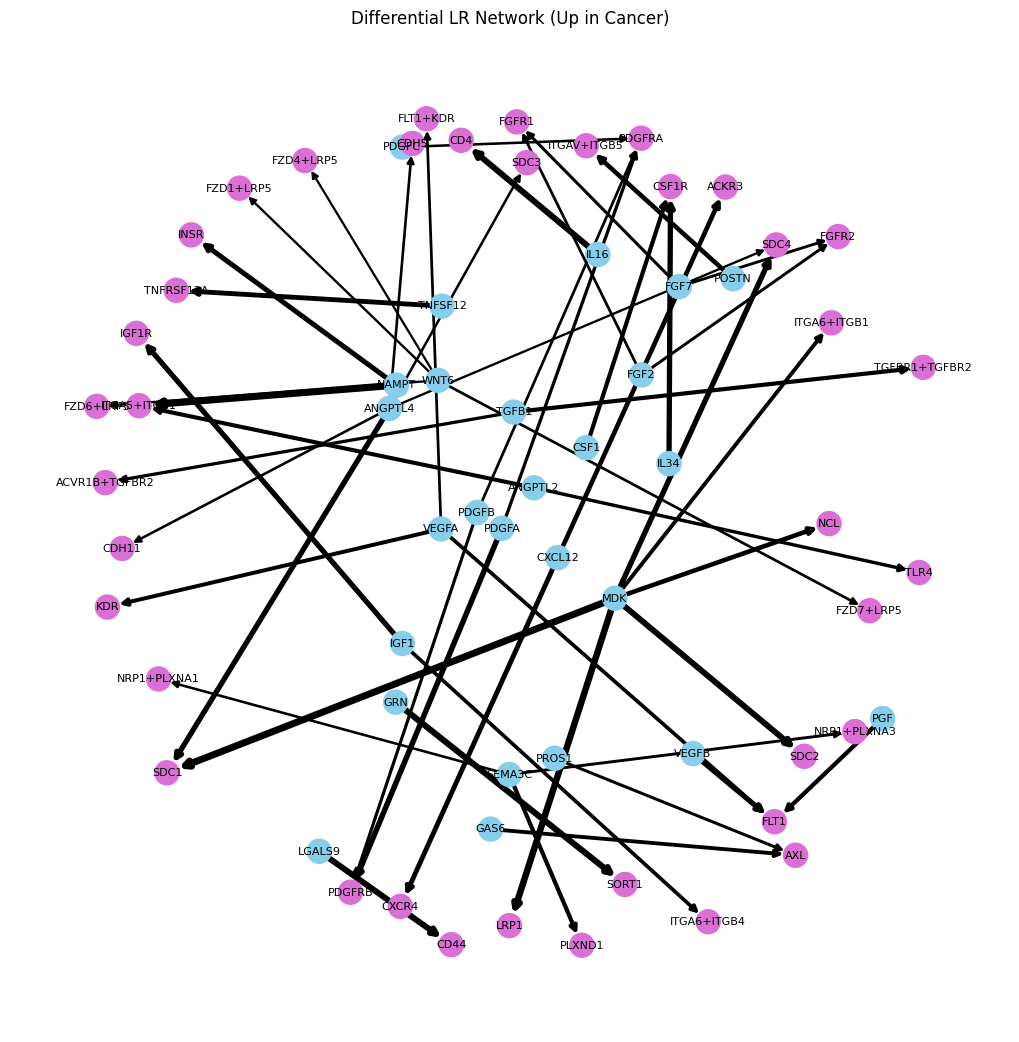

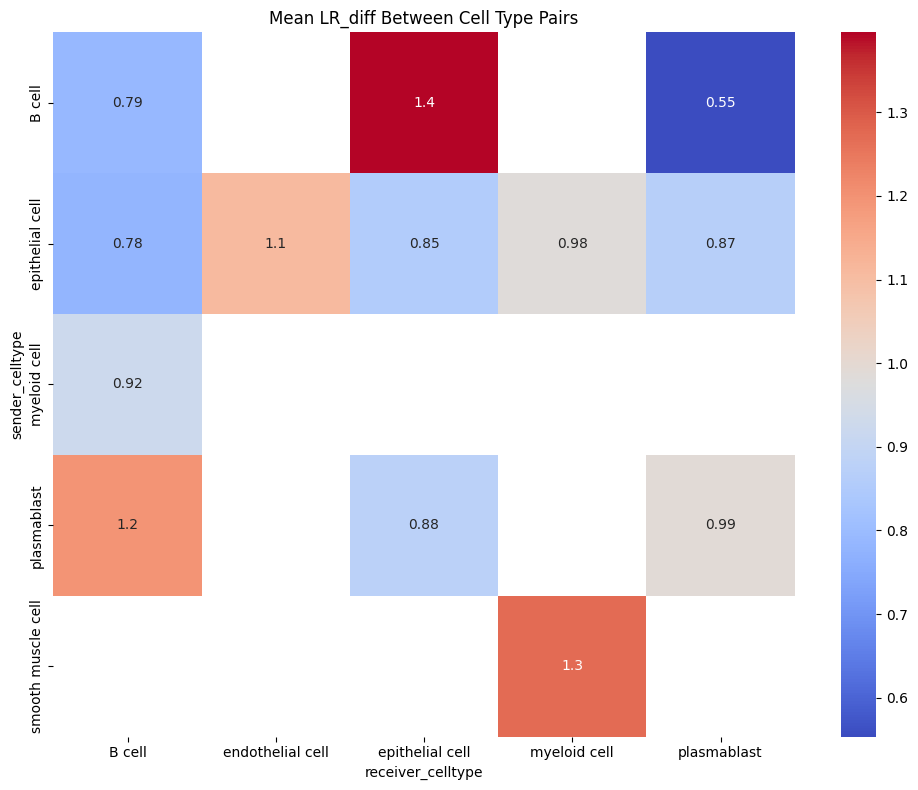

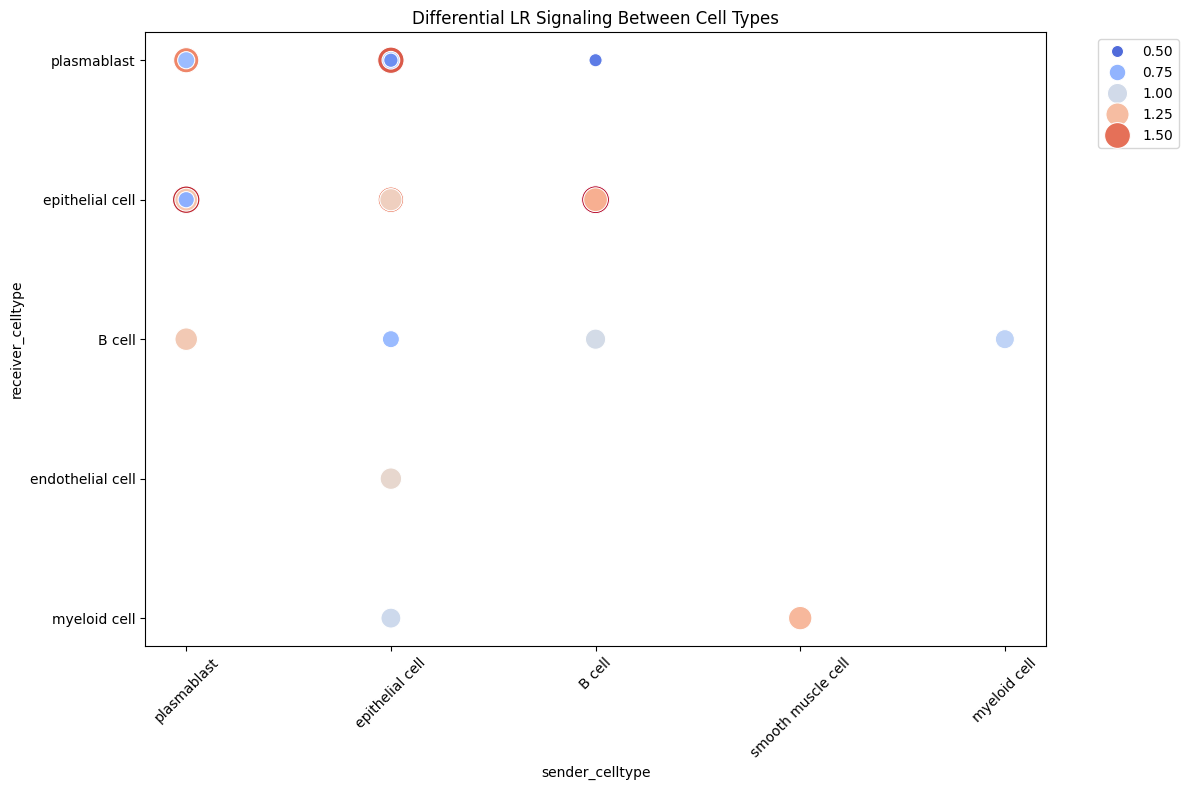

In [79]:
result = analyze_lr_programs(
    df_max=df_max,
    lr_diff=lr_diff,
    sender_canc=sender_canc,
    df_cancer=df_cancer
)

# LIANA+ Attempt

In [ ]:
!pip install liana

In [ ]:
import liana as li

In [ ]:
from liana.method import singlecellsignalr, connectome, cellphonedb, natmi, logfc, cellchat, geometric_mean

## Breast_Cancer_Coutant

In [ ]:
adata = sc.read_h5ad("/kaggle/input/breast-cancer-coutant/Breast_Cancer.h5ad" ) 

In [ ]:
adata

In [ ]:
res = li.resource.select_resource("consensus")
def normalize_sym(s):
    return str(s).strip()

symbols = pd.unique(pd.concat([res['ligand'], res['receptor']]).map(normalize_sym))
symbols = symbols[~pd.isna(symbols)]
symbols_list = symbols.tolist()

In [ ]:
res

In [ ]:
mg = mygene.MyGeneInfo()

In [ ]:
hits = mg.querymany(
    symbols_list,
    scopes="symbol",
    fields=["ensembl.gene", "ensembl", "symbol", "taxid"],
    species=9606,
    as_dataframe=False,
    returnall=False,
    verbose=False,
    batch_size=1000,
)

In [ ]:
def extract_ensembl_gene(x):
    """
    mygene 'ensembl' field can be:
      - dict with 'gene'
      - list of dicts with 'gene'
      - sometimes just a string (rare)
    Return the first gene-like 'ENSG...' we find, else None.
    """
    if x is None:
        return None
    if isinstance(x, dict):
        g = x.get('gene')
        return str(g).split('.')[0] if g else None
    if isinstance(x, list):
        for d in x:
            if isinstance(d, dict) and 'gene' in d and d['gene']:
                return str(d['gene']).split('.')[0]
    # fallback: direct string
    s = str(x)
    return s.split('.')[0] if s.startswith(("ENSG","ENSMUSG")) else None

sym2ens = {}
for rec in hits:
    # rec has keys: 'query', 'notfound' (optional), 'ensembl' (optional), etc.
    q = rec.get('query')
    if not q:
        continue
    # Only accept human mappings (taxid == 9606) when present
    if 'taxid' in rec and str(rec['taxid']) != '9606':
        continue
    ens = None
    if 'ensembl' in rec:
        ens = extract_ensembl_gene(rec['ensembl'])
    # If multiple results came for a symbol, keep the first valid mapping only
    if q not in sym2ens and ens:
        sym2ens[q] = ens

# Optionally check coverage:
n_total = len(symbols_list)
n_mapped = sum(1 for s in symbols_list if s in sym2ens)
print(f"Mapped {n_mapped}/{n_total} symbols to Ensembl.")

# --- 4) Apply mapping to ligand/receptor columns; drop unmapped pairs ---
res_ens = res.copy()
res_ens['ligand']   = res_ens['ligand'].map(sym2ens)
res_ens['receptor'] = res_ens['receptor'].map(sym2ens)
res_ens = res_ens.dropna(subset=['ligand','receptor']).drop_duplicates()

In [ ]:
res_ens

In [ ]:
adata.var_names

In [ ]:
adata.var_names_make_unique()

In [ ]:
cellphonedb(adata,
            groupby='cell_type', 
            # NOTE by default the resource uses HUMAN gene symbols
            resource_name= None,
            resource=res_ens,
            use_raw = False,
            expr_prop=0.05,
            verbose=True, key_added='liana_res')

In [ ]:
adata.uns['liana_res'].head(30)

In [ ]:
my_plot = li.pl.tileplot(adata = adata, 
                         # NOTE: fill & label need to exist for both
                         # ligand_ and receptor_ columns
                         fill='means',
                         label='props',
                         label_fun=lambda x: f'{x:.2f}',
                         top_n=10, 
                         orderby='cellphone_pvals',
                         orderby_ascending=True,
                         source_labels=['malignant cell'],
                         target_labels=['fibroblast','myeloid cell', 'epithelial cell'],
                         uns_key='liana_res', # NOTE: default is 'liana_res'
                         source_title='Ligand',
                         target_title='Receptor',
                         figure_size=(8, 7)
                         )
my_plot

In [ ]:
adata.layers['counts'] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [ ]:
adata

In [ ]:
plot, _ = li.ut.query_bandwidth(coordinates=adata.obsm['spatial'], start=0, end=500, interval_n=20)
plot

In [ ]:
li.ut.spatial_neighbors(adata, bandwidth=500, cutoff=0.1, kernel='gaussian', set_diag=True)

In [ ]:
li.pl.connectivity(adata, idx=0, size=1.3, figure_size=(6, 5))

In [ ]:
lrdata = li.mt.bivariate(adata,
                resource_name=None, # NOTE: uses HUMAN gene symbols!
                resource = res_ens,
                local_name='cosine', # Name of the function
                global_name="morans", # Name global function
                n_perms=50, # Number of permutations to calculate a p-value
                mask_negatives=False, # Whether to mask LowLow/NegativeNegative interactions
                add_categories=True, # Whether to add local categories to the results
                nz_prop=0.05, # Minimum expr. proportion for ligands/receptors and their subunits
                use_raw=False,
                verbose=True
                )

In [ ]:
lrdata.obs

In [ ]:
lrdata.var["mean"]

In [ ]:
lrdata

In [ ]:
lrdata.obs_names

In [ ]:
lrdata.var_names

In [ ]:
def to_ndarray(layer):
    if sparse.issparse(layer):
        return layer.A
    return np.asarray(layer)

In [ ]:
pvals_df = pd.DataFrame(
    to_ndarray(lrdata.layers["pvals"]),
    index=lrdata.obs_names,        # spots
    columns=lrdata.var_names       # LR pairs, e.g. "TGFB1^TGFBR1_TGFBR2"
)
pvals_df.shape

In [ ]:
pvals_df

In [ ]:
lrdata.var.sort_values("mean", ascending=False).head(3)

In [ ]:
lrdata.var[lrdata.var.index == "ENSG00000164692^ENSG00000115884"]

In [ ]:
print("layers:", list(lrdata.layers.keys()))
for k in lrdata.layers.keys():
    try:
        print(k, lrdata.layers[k].shape)
    except Exception:
        pass

print("obsm:", list(lrdata.obsm_keys()))
for k in lrdata.obsm_keys():
    try:
        print(k, lrdata.obsm[k].shape)
    except Exception:
        pass

In [ ]:
interaction = "ENSG00000164692^ENSG00000115884"

# spots with p-value < 0.05
sig_spots = pvals_df[pvals_df[interaction] < 0.05]["ENSG00000164692^ENSG00000115884"]

# how many?
print(f"Significant spots for {interaction}: {sig_spots.shape[0]} out of {pvals_df.shape[0]}")

# preview first few
sig_spots.head()

In [ ]:
assert "cell_type" in lrdata.obs.columns, "No cell_type column found in lrdata.obs!"

# 2️⃣ Extract the cell types of the significant spots
sig_celltypes = lrdata.obs.loc[sig_spots.index, "cell_type"]

# 3️⃣ Count how many of each cell type are significant
counts = sig_celltypes.value_counts()
print(counts)

# 4️⃣ (Optional) convert to DataFrame for plotting or export
counts_df = counts.reset_index()
counts_df.columns = ["cell_type", "num_significant_spots"]
counts_df
